# **House prices analysis project**

## **Author**
Ophélie Rutschmann

## **Introduction**
In this project, I am working with a house price dataset assembled and published by Dean De Cock. This dataset contains 2930 observations with 82 features each. The original data (obtained directly from the Ames Assessor’s Office) was used for tax assessment purposes. 

The goal of this project is to fit and evaluate models that estimate the house prices based on the features in the dataset. 

The models will be fitted on a training set containing the 2430 first observations and tested on a test set containing the last 500 observations. The predictions can be found in the predictions.csv files

## **Methods**

This project is separated into the following sections. Each section can be found in a separate jupyter lab notebook. 

### **Section 1) Exploratory data analysis and data cleaning** 

The goal of this section is to gain a comprehensive overview of the data by exploring and visualising it in various ways. This is used to identify issues with the data that require cleaning (incorrect and missing values, inconsistencies in the variables, outliers). 

**2) Feature engineering and encoding**

**3) Splitting the data (training, validation and test sets)**

**4) Model fitting and evaluation**

**5) Predicting on the test data**

Each Section is presented in its own jupyter lab notebook

## **Academic Integrity and Learning Statement**

By submitting my work, I confirm that:

- The code, analysis, and documentation in this notebook are my own work and reflect my own understanding.
- I am prepared to explain all code and analysis included in this submission.

If I used assistance (e.g., AI tools, tutors, or other resources), I have:

- Clearly documented where and how external tools or resources were used in my solution.
- Included a copy of the interaction (e.g., AI conversation or tutoring notes) in an appendix.

I acknowledge that:

- I may be asked to explain any part of my code or analysis during evaluation.
- Misrepresenting assisted work as my own constitutes academic dishonesty and undermines my learning.


## **Section 1: Exploratory data analysis and data cleaning**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Import the data set
data = pd.read_csv("house-prices.csv")
data.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,484,528275070,60,RL,NaN,8795,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,236000
1,2586,535305120,20,RL,75.0,10170,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,155000
2,2289,923228250,160,RM,21.0,2001,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,75000
3,142,535152150,20,RL,70.0,10552,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,165500
4,2042,903475060,190,RM,60.0,10120,Pave,NaN,IR1,Bnk,...,0,NaN,MnPrv,NaN,0,1,2007,WD,Normal,122000


## **1) Preliminary data cleaning**
Before diving into the exploratory data analysis, we can already gain some understanding of our data set and do some preliminary data cleaning steps such as
- Removing duplicated rows
- Removing entirely empty rows / columns

### **1.1) Preliminary data set exploration**

Based on the description in the data documentation, we know that the data contains 82 columns:
- 23 nominal variables
- 23 ordinal variables
- 14 discrete variables
- 20 continuous variables
- 2 additional observation identifiers

We can check our data frame to make sure this is what we have. 

In [3]:
print(data.columns)

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [4]:
print(data.shape)

(2430, 82)


It looks like our data set contains the expected columns and consists of 2430 entries with 82 features each. 

### **1.2) Removing duplicated rows**
Let's now check if our data set contains any duplicated rows, and if yes, let's remove them.

In [5]:
print("our data set contains", data.duplicated().sum(), "duplicated rows")

our data set contains 0 duplicated rows


Good! It looks like our data set does not contain duplicated rows!

### **1.3) Removing entirely empty rows or columns**
Let's check if any rows or columns are entirely empty, and if yes, let's remove them.

In [6]:
print("our data set contains", data.isna().all(axis=1).sum(), "empty rows")
print("our data set contains", data.isna().all(axis=0).sum(), "empty columns")

our data set contains 0 empty rows
our data set contains 0 empty columns


Perfect, we have zero empty rows or columns. We can move on to the next steps.

## **2) Exploratory data analysis**

We can now perform some more in depth exploratory data analysis on our data set. We will perform this data analysis independently for each type of variable (nominal, ordinal, discrete and continuous). 

We will start by creating variables that contain the column names for each type of variable.

In [7]:
# create variables with the column names
nom_col = ["MS SubClass", "MS Zoning", "Street", "Alley", "Land Contour", 
           "Lot Config", "Neighborhood", "Condition 1", "Condition 2", "Bldg Type", "House Style",
           "Roof Style", "Roof Matl", "Exterior 1st", "Exterior 2nd", "Mas Vnr Type", "Foundation", 
           "Heating", "Central Air", "Garage Type", "Misc Feature", "Sale Type", "Sale Condition"]

ord_col = ["Lot Shape", "Utilities", "Land Slope", "Overall Qual", "Overall Cond", "Exter Qual", 
           "Exter Cond", "Bsmt Qual", "Bsmt Cond", "Bsmt Exposure", "BsmtFin Type 1", "BsmtFin Type 2",
           "Heating QC", "Electrical", "Kitchen Qual", "Functional", "Fireplace Qu", "Garage Finish", 
           "Garage Qual", "Garage Cond", "Paved Drive", "Pool QC", "Fence"]

disc_col = ["Year Built", "Year Remod/Add", "Bsmt Full Bath", "Bsmt Half Bath", "Full Bath", 
            "Half Bath", "Bedroom AbvGr", "Kitchen AbvGr", "TotRms AbvGrd", "Fireplaces", "Garage Yr Blt", 
            "Garage Cars", "Mo Sold", "Yr Sold"]

cont_col = ["Lot Frontage", "Lot Area", "Mas Vnr Area", "BsmtFin SF 1", "BsmtFin SF 2", "Bsmt Unf SF",
            "Total Bsmt SF", "1st Flr SF", "2nd Flr SF", "Low Qual Fin SF", "Gr Liv Area", "Garage Area", 
            "Wood Deck SF", "Open Porch SF", "Enclosed Porch", "3Ssn Porch", "Screen Porch", "Pool Area", 
            "Misc Val"]

ids = ["Order", "PID"]

Now that we have created the lists with the column names, we can explore each of the variables. 

### **2.1) Exploring the continuous variables**

We will start by exploring the continuous variables by creating visualisations such as scatter plots and histograms to understand what the distributions look like, if there are variables that we want to remove, and what the best strategy for data cleaning is. 

#### **a) Identifying missing values**

Let's first have a look to see if we observe any missing values. We will work on a copy of the data frame for all of the future data cleaning steps

In [8]:
df = data.copy()
print(df.shape)

(2430, 82)


In [9]:
# identify missing values
for col in cont_col:
    print("Missing values for", col, ":", df[col].isna().sum(), "(", df[col].isna().sum() / len(df) * 100, "% )")

Missing values for Lot Frontage : 420 ( 17.28395061728395 % )
Missing values for Lot Area : 0 ( 0.0 % )
Missing values for Mas Vnr Area : 20 ( 0.823045267489712 % )
Missing values for BsmtFin SF 1 : 1 ( 0.0411522633744856 % )
Missing values for BsmtFin SF 2 : 1 ( 0.0411522633744856 % )
Missing values for Bsmt Unf SF : 1 ( 0.0411522633744856 % )
Missing values for Total Bsmt SF : 1 ( 0.0411522633744856 % )
Missing values for 1st Flr SF : 0 ( 0.0 % )
Missing values for 2nd Flr SF : 0 ( 0.0 % )
Missing values for Low Qual Fin SF : 0 ( 0.0 % )
Missing values for Gr Liv Area : 0 ( 0.0 % )
Missing values for Garage Area : 1 ( 0.0411522633744856 % )
Missing values for Wood Deck SF : 0 ( 0.0 % )
Missing values for Open Porch SF : 0 ( 0.0 % )
Missing values for Enclosed Porch : 0 ( 0.0 % )
Missing values for 3Ssn Porch : 0 ( 0.0 % )
Missing values for Screen Porch : 0 ( 0.0 % )
Missing values for Pool Area : 0 ( 0.0 % )
Missing values for Misc Val : 0 ( 0.0 % )


We observe that the data contains relatively few missing values in the continuous columns. The two main problematic columns are:
- Lot Frontage (The linear feet of street connected to the property)
- Mas Vnr Area (the area of the house that has masonry)

##### **Adressing the Lot Frontage feature**
We will start by looking into more detail into the lot frontage variable. We can plot a histogram of this variable and it's relationship to the sale price. This can allow us to see if we could take the mean or the median of the distribution to fill in the missing values

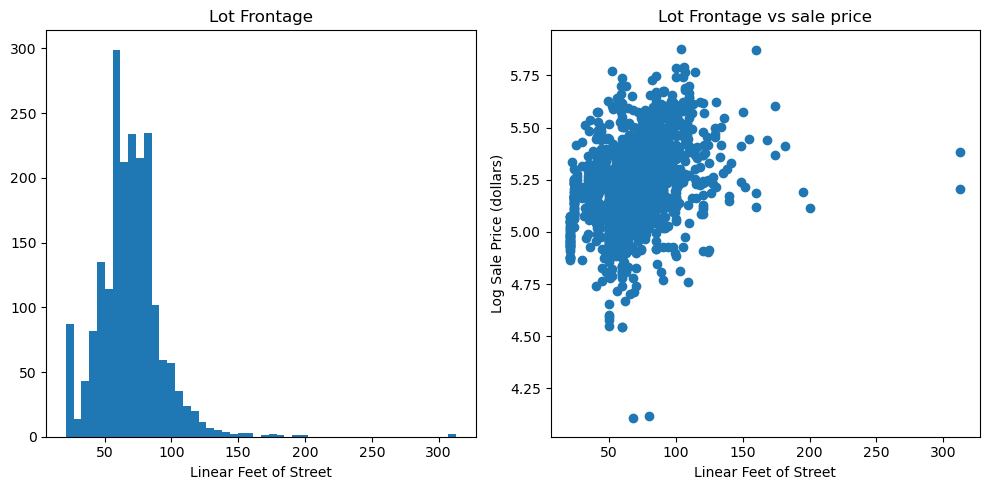

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].hist(df["Lot Frontage"], bins=50)
axes[0].set_title("Lot Frontage")
axes[0].set_xlabel("Linear Feet of Street")

axes[1].scatter(x=df["Lot Frontage"], y=np.log10(df["SalePrice"]))
axes[1].set_title("Lot Frontage vs sale price")
axes[1].set_xlabel("Linear Feet of Street")
axes[1].set_ylabel("Log Sale Price (dollars)")
plt.tight_layout()
plt.show()

These plots show us that the distribution seems to contain a tail to the right. Taking the mean of the distribution is thus likely not a good approach to fill in the missing values. We could fill in the missing values by taking the median of the distribution. But let's first have a look if there are other variables that could influence the lot frontage (such as the neighbourhood or the zoning of the house) and could help us refine the approache we would like to take to fill in the missing values. 

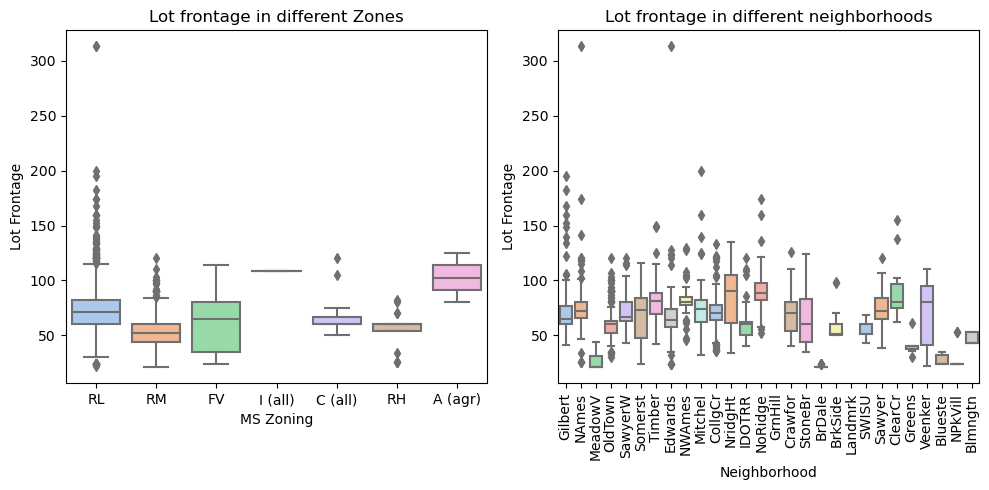

In [11]:
# Let's look if the zoning and neighborhood influences the lot frontage
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.boxplot(data=df, x="MS Zoning", y="Lot Frontage", ax=axes[0], palette="pastel")
axes[0].set_title("Lot frontage in different Zones")
sns.boxplot(data=df, x="Neighborhood", y="Lot Frontage", ax=axes[1], palette="pastel")
axes[1].set_title("Lot frontage in different neighborhoods")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

Both the zonage and the neighborhood seem to have an effect on the lot frontage. Taking the median lot frontage for each zone or each neighborhood could both thus be viable approaches to fill in the missing values. 

I have decided to take the median value of the lot frontage depending on the neighborhood, as this approach seems more refined (there are more neighborhoods than zones). 

In [12]:
# obtain the median lot frontage for each neighborhood
med_nbrh = df.groupby("Neighborhood")["Lot Frontage"].median()

# make a list that contains the median lot frontage of each house's neighborhood
med_lot_frontage = df["Neighborhood"].map(med_nbrh.to_dict())

# replace the values with the values in this list
df["Lot Frontage"] = df["Lot Frontage"].fillna(med_lot_frontage)

print("after cleaning, we have", df["Lot Frontage"].isna().sum(), "missing values")

after cleaning, we have 3 missing values


This approach filled all of the missing values except for 3 (likely houses that don't have a neighborhood specified). For these houses, we can fill the missing values using the median of the whole data set.

In [13]:
df["Lot Frontage"] = df["Lot Frontage"].fillna(df["Lot Frontage"].median())

print("after cleaning, we have", df["Lot Frontage"].isna().sum(), "missing values")

after cleaning, we have 0 missing values


##### **Adressing the Mas Vnr Area feature**
The next column we would like to adress is the column Mas Vnr Area (the area of the house that has masonry)

We will start by making a histogram of this variable and it's relationship to the sale price.

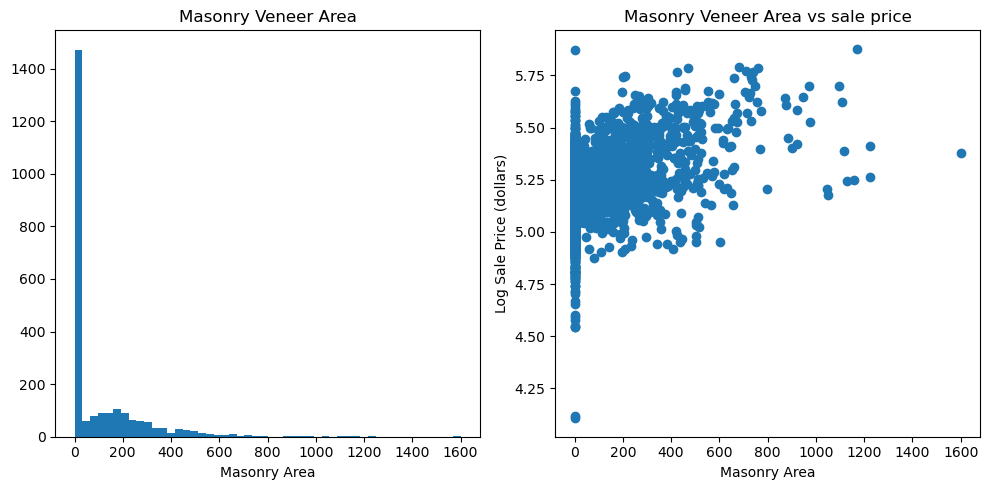

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].hist(df["Mas Vnr Area"], bins=50)
axes[0].set_title("Masonry Veneer Area")
axes[0].set_xlabel("Masonry Area")

axes[1].scatter(x=df["Mas Vnr Area"], y=np.log10(df["SalePrice"]))
axes[1].set_title("Masonry Veneer Area vs sale price")
axes[1].set_xlabel("Masonry Area")
axes[1].set_ylabel("Log Sale Price (dollars)")
plt.tight_layout()
plt.show()

We immediately see that a lot of the houses have a Masonry Veneer Area of 0, likely meaning that they do not have any masonry veneer. This is an issue of itself that we can adress later on. For now, we can take the approach of filling the missing values with a 0 as well.

In [15]:
df["Mas Vnr Area"] = df["Mas Vnr Area"].fillna(0)

df["Mas Vnr Area"].isna().sum()

0

##### **Filling in the other missing values**
Finally, for all of the other continuous variables with missing values, we can also replace them with 0, indicating the absence of the feature

In [16]:
df[cont_col] = df[cont_col].fillna(0)

df[cont_col].isna().sum()

Lot Frontage       0
Lot Area           0
Mas Vnr Area       0
BsmtFin SF 1       0
BsmtFin SF 2       0
Bsmt Unf SF        0
Total Bsmt SF      0
1st Flr SF         0
2nd Flr SF         0
Low Qual Fin SF    0
Gr Liv Area        0
Garage Area        0
Wood Deck SF       0
Open Porch SF      0
Enclosed Porch     0
3Ssn Porch         0
Screen Porch       0
Pool Area          0
Misc Val           0
dtype: int64

#### **b) Identifying values with the wrong data type**

Now that we have filled in any missing values, we can quickly have a look if we see any other problematic values in the variables. These are continuous variable, the data type should be numerical. We can check if this is the case for all of the values.

In [17]:
df[cont_col].dtypes

Lot Frontage       float64
Lot Area             int64
Mas Vnr Area       float64
BsmtFin SF 1       float64
BsmtFin SF 2       float64
Bsmt Unf SF        float64
Total Bsmt SF      float64
1st Flr SF           int64
2nd Flr SF           int64
Low Qual Fin SF      int64
Gr Liv Area          int64
Garage Area        float64
Wood Deck SF         int64
Open Porch SF        int64
Enclosed Porch       int64
3Ssn Porch           int64
Screen Porch         int64
Pool Area            int64
Misc Val             int64
dtype: object

All of the variables seem to contain the correct data type, either float or int.

#### **c) Identifying and removing incorrect values**

Before we adress outliers and 0s in the data set, we can have a look at whether the values in our features are plausible. There are some things that cannot occur and that are worth quickly checking in our data set: 
- House Area and Garage Area cannot be bigger than lot area
- Greater Living Area should be equal to or bigger than the sum of 1st floor and 2nd floor living area
- Total Basement Area should be equal to or greater than BsmtFin Sf 1

Let's quickly check if these mistakes appear anywhere in our data, and if yes, let's remove the corresonpding entries. I added a tolearnce of 5%.

In [18]:
print("House area bigger than Lot area:", (df["Gr Liv Area"] > df["Lot Area"] * 1.05).sum())
print("Garage area bigger than Lot area:", (df["Garage Area"] > df["Lot Area"] * 1.05).sum())
print("Basement area bigger than finished basement area:", (df["BsmtFin SF 1"] > df["Lot Area"] * 1.05).sum())

sum_area = df["1st Flr SF"] + df["2nd Flr SF"]
print("Living area inconsistent:", (df["Gr Liv Area"] * 1.05 < sum_area).sum())

House area bigger than Lot area: 0
Garage area bigger than Lot area: 0
Basement area bigger than finished basement area: 0
Living area inconsistent: 0


The data seems to be in good shape, with no values that are inconsistent

#### **d) Removing features with low correlation to Sale Price**
Before we do more computationally intensive operations, let's see if it is important to keep all of the features. To identify variables with a low correlation to the sale price, we wil calculate the correlation and make scatter plots to plot the relationship between each of the variables and the variable we want to predict (the dependent variable, i.e. the Sale Price)

In [19]:
# Correlation
correlations_cont = df[cont_col + ["SalePrice"]].corr()["SalePrice"]
correlations_cont = correlations_cont.sort_values(ascending=False)
correlations_cont = correlations_cont.drop("SalePrice")

print(correlations_cont)

Gr Liv Area        0.700147
Total Bsmt SF      0.635624
Garage Area        0.630500
1st Flr SF         0.625882
Mas Vnr Area       0.505979
BsmtFin SF 1       0.439867
Lot Frontage       0.355071
Wood Deck SF       0.315521
Open Porch SF      0.301212
Lot Area           0.252444
2nd Flr SF         0.245014
Bsmt Unf SF        0.180648
Screen Porch       0.120009
Pool Area          0.072138
3Ssn Porch         0.039017
BsmtFin SF 2       0.013217
Misc Val          -0.016804
Low Qual Fin SF   -0.029989
Enclosed Porch    -0.138282
Name: SalePrice, dtype: float64


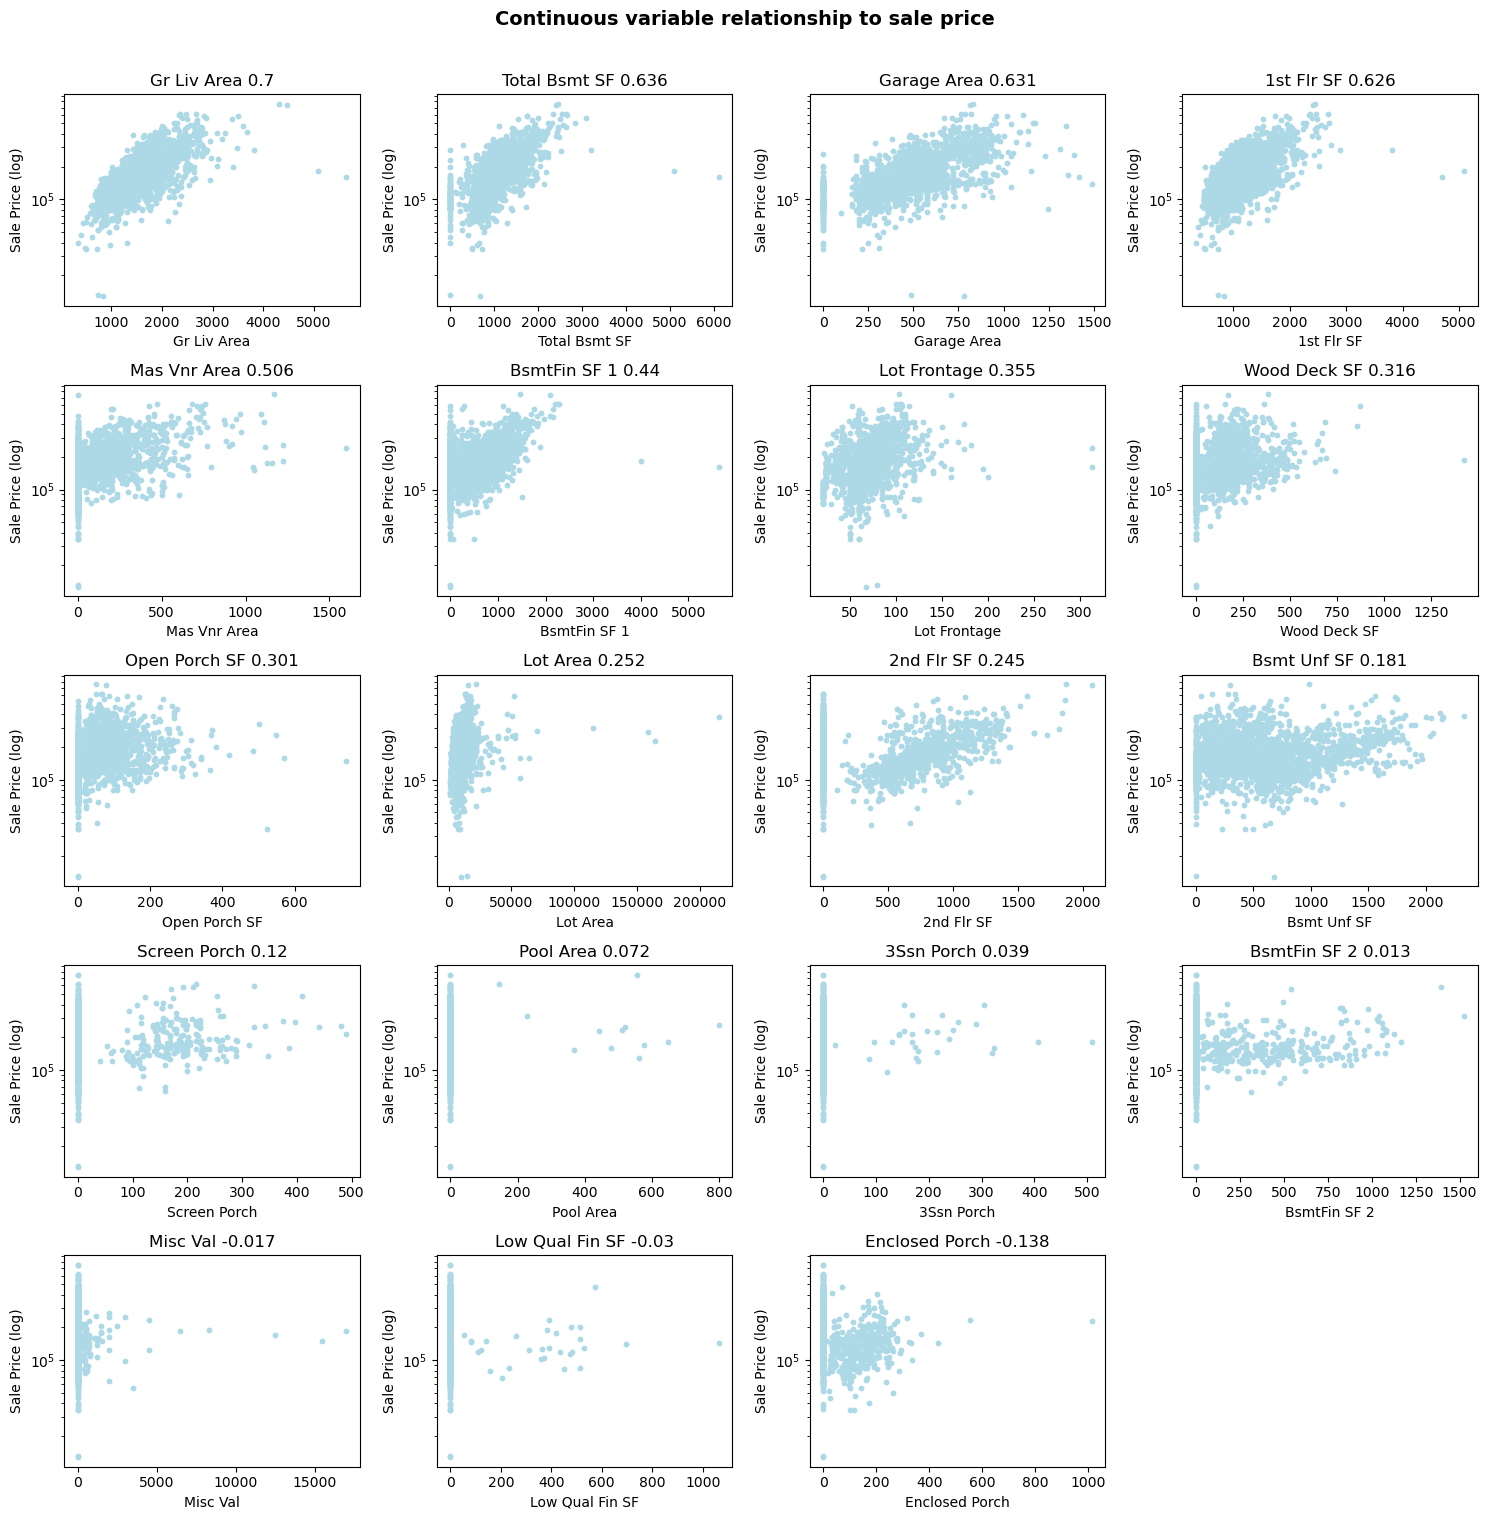

In [20]:
# Scatter plots for the continuous columns 
import math

# compute the number of rows and columns for the subplot
n_cols = 4
n_rows = math.ceil(len(cont_col) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 15))
axes = axes.flatten()

for col, i in zip(correlations_cont.index, range(len(correlations_cont.index))):
        axes[i].scatter(data[col], data["SalePrice"], s=10, color="lightblue")
        axes[i].set_title(str(col) + " " + str(round(correlations_cont[col], 3)))
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Sale Price (log)")
        axes[i].set_yscale("log")

# Remove unused subplots
for j in range(len(cont_col), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Continuous variable relationship to sale price", fontsize=14, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()

Based on these plots, we can already make the decision to remove some of the variables from the model, as they do not seem to hold predictive power. Indeed, none of these variables seem to be correlated to the sale price. 

The variables that we could remove are: 
- Low Qual Fin SF: there seems to be no link between this variable and the sale Price at all. Also very few house have this feature, so it likely makes sense to remove it. 
- Misc Val (same reasoning as above)
- BsmtFin SF 2
- Bsmt Unf SF

These variables can be removed using .drop().

I have made the decision to keep all of the Porch variables, as there could be an effect when they are combined into a single variable (we can have a look at this in the feature engineering step). 

Interestingly, we observe that there are a lot of values set to 0 for some of the variables, we will look into this in more detail further on. 


In [21]:
df = df.drop(["BsmtFin SF 2", "Bsmt Unf SF", "Low Qual Fin SF", "Misc Val"], axis=1)

# create your new list of column names
cont_col_clean = [column for column in cont_col if column not in ("BsmtFin SF 2", "Bsmt Unf SF", "Low Qual Fin SF", "Misc Val")]


#### **e) Identifying and removing outliers**

To assess the distribution of the remaining continuous variables and determine the best data cleaning strategy, I will plot histograms for each of the variables

/home/ruop/miniconda3/envs/adsml/lib/python3.9/site-packages/pandas/plotting/_core.py:1746: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


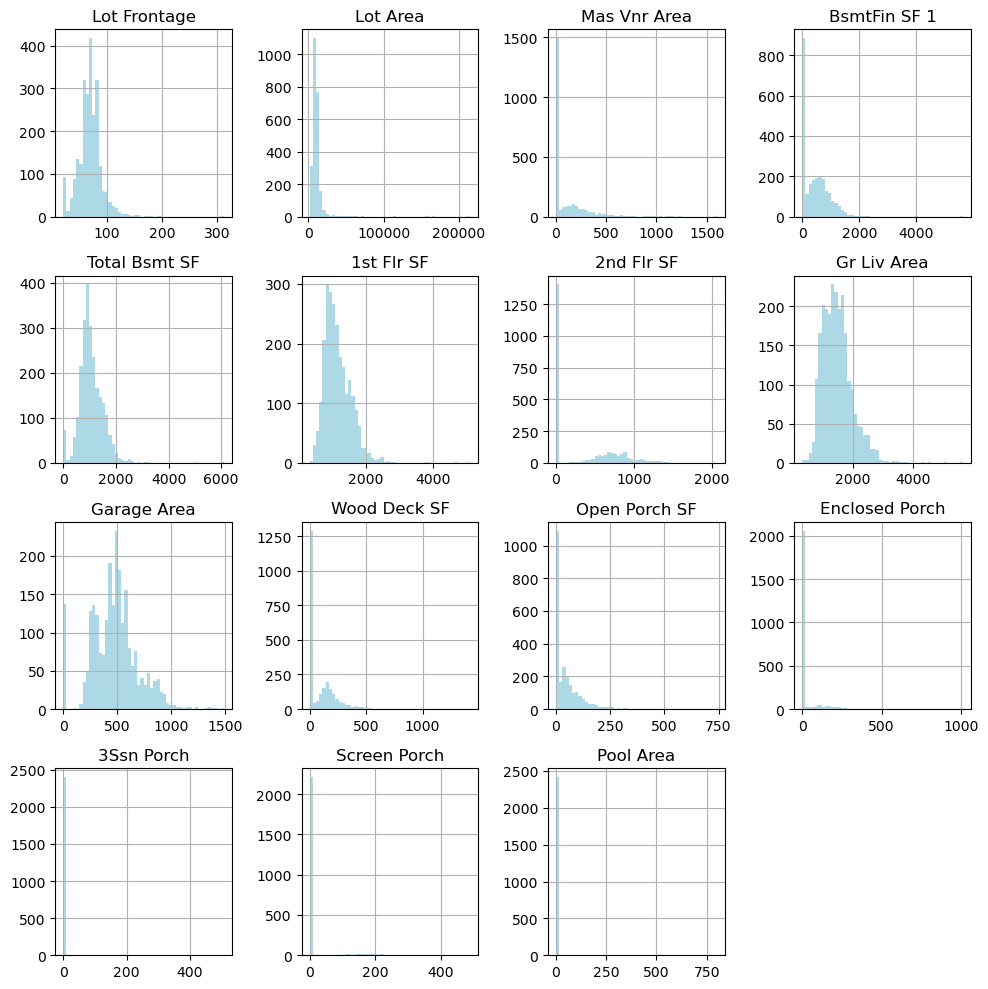

In [22]:
df[cont_col_clean].hist(color="lightblue", bins=50, figsize = (10,10))
plt.tight_layout()
plt.show()

We notice that a lof of the features seem to contain a "tail" and have a some very large values. This is something we should adress. 

There are several ways to adress this. We could: 
- log transform the variables (this ensures that the z score is less skewed towards big values)
- remove outliers (using a z score)

Additionally, we notice that most of these variables have a lot of 0 in them (probably to indicate the absence of the item in the variable, i.e. a house that has a 0 in the wood deck SF variable likely doesn't have a wood deck). This will be treated in another step after outlier removal. 


##### **Log transforming the data**
We can see if it would make sense to log transform the data (to have distributions that more closely ressemble a gaussian distribution. 

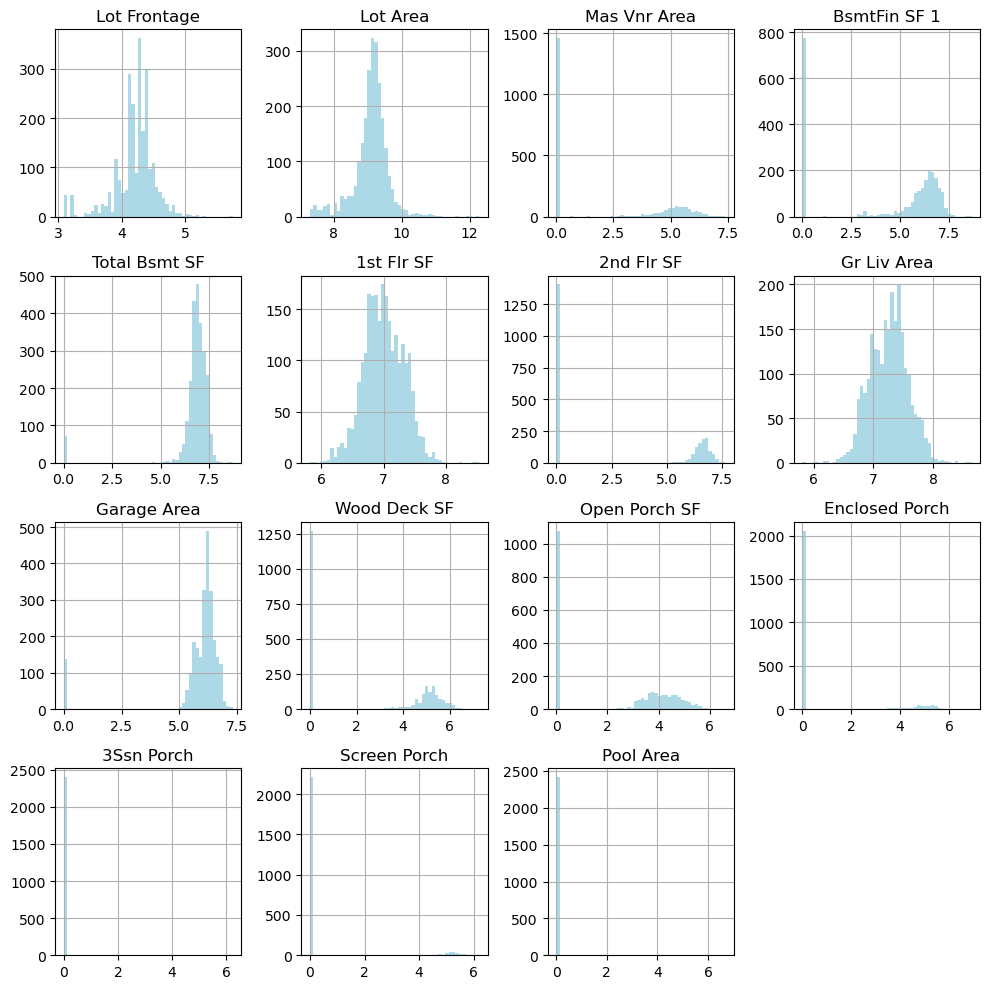

In [23]:
# Log transform the data
# plot the long transformed data
np.log1p(df[cont_col_clean]).hist(color="lightblue", bins=50, figsize = (10,10))
plt.tight_layout()
plt.show()

By plotting the log transformed data, we directly see that a lot of the features benefit from being log transformed as the distribution now more closely resembles a gaussian distribution. 

Let's thus apply a log transformation to all of the continuous features. 

In [24]:
df[cont_col_clean] = np.log1p(df[cont_col_clean])

##### **Removing extreme values using a z score**

We would like to remove very big houses from the data set as they likely correspond to "mansions" that could negatively influence or models. To do this, we can remove entries that have a very large above ground surface area or lot area. 

Additionally, we can also remove entries that have a very small value for some of the features (such as lot frontage) as these are likely "out of the norm" property that might not be very useful for our model.

We can do this data cleaning step using a z score.

The features we wish to adress in this way are: 
- Lot Frontage
- Lot Area
- 1st Flr SF
- Gr Liv Area

Note that I am not applying this step to the features that contain a lot of 0s, as not only would this skew the z score, but also the 0s would likely be removed and they could contain valuable information. 

In [25]:
# calculate a z score
z_scores = (df.loc[:, ("Lot Frontage", "Lot Area", "1st Flr SF", "Gr Liv Area")] - df.loc[:, ("Lot Frontage", "Lot Area", "1st Flr SF", "Gr Liv Area")].mean(axis=0)) / df.loc[:, ("Lot Frontage", "Lot Area", "1st Flr SF", "Gr Liv Area")].std(axis=0)
outliers = (np.abs(z_scores) > 3)

# create a row filter where a row will be removed if any one of the features contains an outlier
outliers = ~ (outliers.sum(axis=1) > 0)

# Print the percentage / number of values we would remove using this setp
print("using a z score removes:", (~outliers).sum(), "rows")
print("this corresponds to:", (~outliers).sum() / len(df) * 100, "% of the data")

using a z score removes: 120 rows
this corresponds to: 4.938271604938271 % of the data


This technique would seem to remove a reasonable amount of our data. let's apply the filter.

In [26]:
# print the size of the data frame before filtering
print("shape before filtering:", df.shape)
df = df[outliers]
print("shape after filtering:", df.shape)

shape before filtering: (2430, 78)
shape after filtering: (2310, 78)


Let's plot the data again to make sure our cleaning strategy has worked

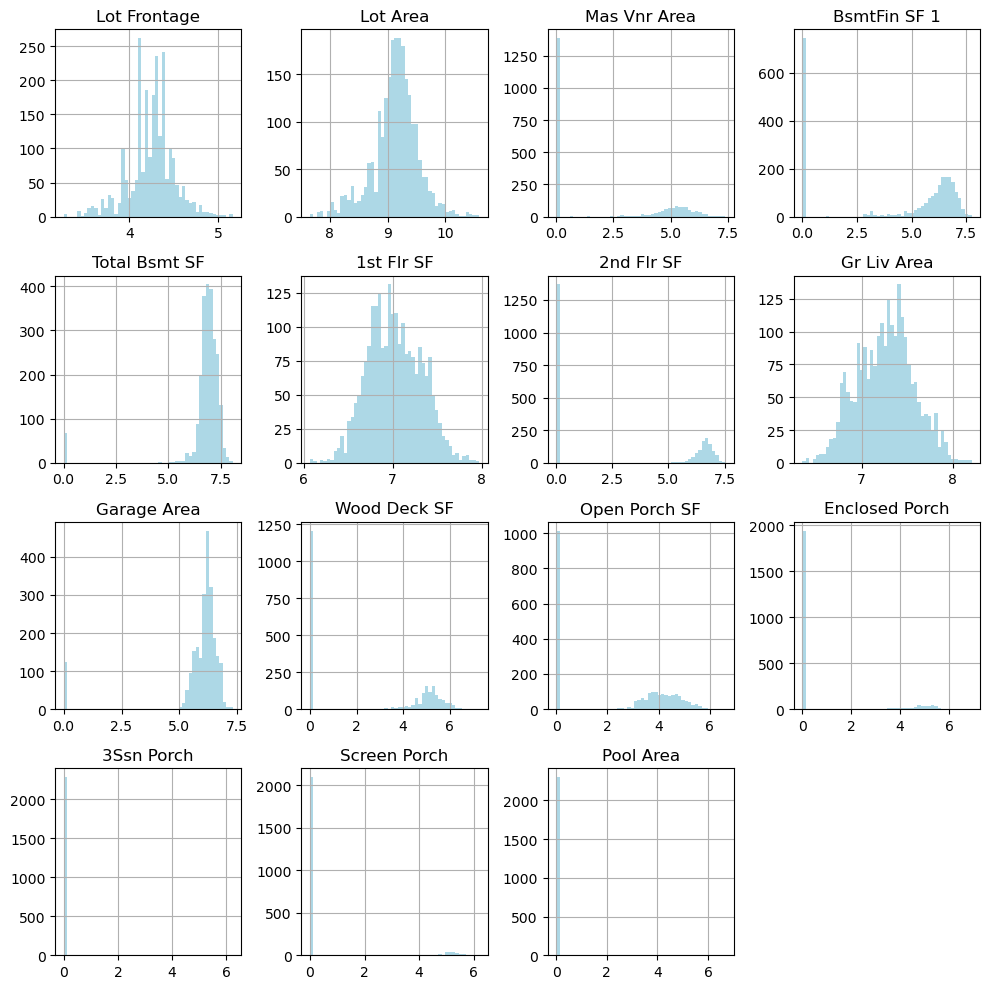

In [27]:
df[cont_col_clean].hist(color="lightblue", bins=50, figsize = (10,10))
plt.tight_layout()
plt.show()

We see that our outlier removal strategy seemed to have worked well, with the distributions now containing less extreme values.

#### **f) Adressing the 0s** (Move to feature engineering?)

The dataset originally contains many variables with a lot of 0s. This is probably to indicate the absence of the item in the variable, i.e. a house that has a 0 in the wood deck SF variable likely doesn't have a wood deck). One of the options to treat this is to add a binary variable (e.g. hasDeck, hasPool, etc.). In some cases, we can then remove the original variable (we will do this for the pool area variable, as a big percentage of the houses don't have a pool. In this case, the presence or absence of a pool carries more information than the size of the pool). 

In other cases, we can keep both the binary variable and the original variable, as we can hypothesize that both the presence/absence of the feature and the size of the feature carry predictive power for the model. This is for instance the case for the "Wood Deck" variable.

For the Porch feature, we will create a new feature which will be a summary of the different "Porch" features currently existing. 

In [28]:
# Making indicative (binary variables) for the variables we wish to replace (Pool area and 3 Season porch area)
df["HasPool"] = (df["Pool Area"] > 0).astype(int)
df["Has3SsnPorch"] = (df["3Ssn Porch"] > 0).astype(int)

df = df.drop(["Pool Area", "3Ssn Porch"], axis=1)

We will now make binary (indicative) variables for the other variables with 0s. However, for these variables, we wish to keep the original variable as it also contains interesting information. 

These variables are :
- Open Porch SF
- Wood Deck SF
- Garage Area
- 2nd Floor SF
- Mas Vnr Area
- BsmFin SF 1

In [29]:
# Making binary variables for the other variables with a lot of 0s (without replacing them)
df["HasOpenPorch"] = (df["Open Porch SF"] > 0).astype(int)
df["HasWoodDeck"] = (df["Wood Deck SF"] > 0).astype(int)
df["HasGarage"] = (df["Garage Area"] > 0).astype(int)
df["Has2ndFlr"] = (df["2nd Flr SF"] > 0).astype(int)
df["HasMasonry"] = (df["Mas Vnr Area"] > 0).astype(int)
df["HasBsmt"] = (df["BsmtFin SF 1"] > 0).astype(int)

### **2.2) Explorating the discrete variables**
We will now look at the discrete variables. 


#### **a) Identifying missing values**
Let's start by looking at how much of the data is missing for these columns


In [30]:
# identify missing values
for col in disc_col:
    print("Missing values for", col, ":", df[col].isna().sum(), "(", df[col].isna().sum() / len(df) * 100, "% )") 

Missing values for Year Built : 0 ( 0.0 % )
Missing values for Year Remod/Add : 0 ( 0.0 % )
Missing values for Bsmt Full Bath : 1 ( 0.04329004329004329 % )
Missing values for Bsmt Half Bath : 1 ( 0.04329004329004329 % )
Missing values for Full Bath : 0 ( 0.0 % )
Missing values for Half Bath : 0 ( 0.0 % )
Missing values for Bedroom AbvGr : 0 ( 0.0 % )
Missing values for Kitchen AbvGr : 0 ( 0.0 % )
Missing values for TotRms AbvGrd : 0 ( 0.0 % )
Missing values for Fireplaces : 0 ( 0.0 % )
Missing values for Garage Yr Blt : 125 ( 5.411255411255411 % )
Missing values for Garage Cars : 1 ( 0.04329004329004329 % )
Missing values for Mo Sold : 0 ( 0.0 % )
Missing values for Yr Sold : 0 ( 0.0 % )


We see that the data is in pretty good shape as there are very few missing values. The only feature that is problematic is the Garage Year Built. 

##### **Addressing the Garage Year Built feature**
We will look at this feature in more detail, is it that this feature is empty when there is no garage ? We can use the Garage Area future to check this (if it is equal to 0, it likely means the houses do not have a garage). 

In [31]:
print(((df["Garage Yr Blt"].isna()) & (df["Garage Area"] == 0)).sum(), "out of", df["Garage Yr Blt"].isna().sum(), "values are missing in the feature *Garage Year Built* since there isn't a garage")

124 out of 125 values are missing in the feature *Garage Year Built* since there isn't a garage


It looks like indeed, most of the garage year built don't contain a value (a year) as these houses don't have a garage! We now need to decide what would be the best way to deal with this missing data. 

One thing we could think about is how much information does the feature garage year built contain. In how many cases was the garage actually built on a different year than the house ? If this is minimal, then all of the information of this feature is already contained in the feature "Year Built" and "Garage Area".

We can investigate this by looking at the correlation between "Garage Yr Blt" and "Year Built", as well as the correlation between "Garage Yr Blt" and "SalePrice"

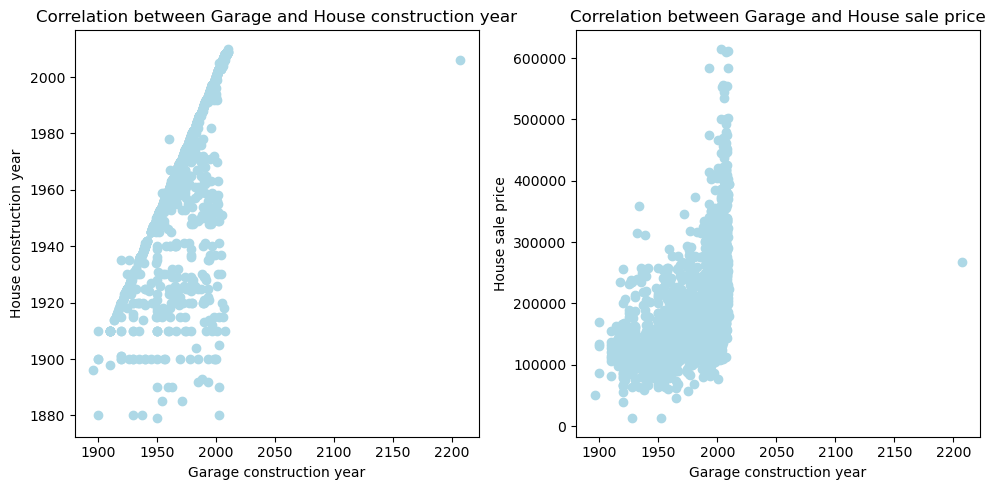

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

axes[0].scatter(x=df["Garage Yr Blt"], y=df["Year Built"], color="lightblue")
axes[0].set_title("Correlation between Garage and House construction year")
axes[0].set_xlabel("Garage construction year")
axes[0].set_ylabel("House construction year")

axes[1].scatter(x=df["Garage Yr Blt"], y=df["SalePrice"], color="lightblue")
axes[1].set_title("Correlation between Garage and House sale price")
axes[1].set_xlabel("Garage construction year")
axes[1].set_ylabel("House sale price")

plt.tight_layout()
plt.show()

In [33]:
print("Percentage of houses where the garage and the house construction date differ:", (df["Garage Yr Blt"] != df["Year Built"]).sum() / df.shape[0])

Percentage of houses where the garage and the house construction date differ: 0.24112554112554113


We see that our previous theory was actually wrong, a big proportion (a quarter) of the entries have a different construction year for the garage and for the house. We can also see on the scatter plots that the feature does seem to contribute to explaining house sale price, so we need to find a way to adress the missing values. One of the option would be to replace the missing value with a 0 for these columns, let's do this. But first, there is one value that is missing whereas the house is reported as having a garage. Let's fill this value with the construction year of the house. 

In [34]:
df.loc[df["Garage Yr Blt"].isna() & (df["Garage Area"] > 0), "Garage Yr Blt"] = df.loc[df["Garage Yr Blt"].isna() & (df["Garage Area"] > 0), "Year Built"]
df["Garage Yr Blt"] = df["Garage Yr Blt"].fillna(0)

##### **Addressing the other features with missing values**

Let's now have a look at the other features with missing values. 

For the features Bsmt Full Bath and Bsmt Half Bath, we can fill the missing value with a 0 (assuming there isn't a full or half bathroom in the basement for these houses). For the Garage Cars, we can have a look if that house has a garage (by using the garage area), and if it does, we can use the median of that feature to fill the missing value. 

In [35]:
df["Bsmt Full Bath"].fillna(0, inplace=True)
df["Bsmt Half Bath"].fillna(0, inplace=True)

In [36]:
df.loc[df["Garage Cars"].isna(), "Garage Area"]

1565    0.0
Name: Garage Area, dtype: float64

We see that this house doesn't have a garage (the Garage Area is 0). We can thus fill in the missing value with a 0 as well!

In [37]:
df["Garage Cars"].fillna(0, inplace=True)

In [38]:
df[disc_col].isna().sum()

Year Built        0
Year Remod/Add    0
Bsmt Full Bath    0
Bsmt Half Bath    0
Full Bath         0
Half Bath         0
Bedroom AbvGr     0
Kitchen AbvGr     0
TotRms AbvGrd     0
Fireplaces        0
Garage Yr Blt     0
Garage Cars       0
Mo Sold           0
Yr Sold           0
dtype: int64

We see that our data now has no more missing values, our data cleaning strategy worked!

#### **b) Identifying features with the wrong data type**

As a sanity check, let's make sure all of the features contain numerical values

In [39]:
df[disc_col].dtypes

Year Built          int64
Year Remod/Add      int64
Bsmt Full Bath    float64
Bsmt Half Bath    float64
Full Bath           int64
Half Bath           int64
Bedroom AbvGr       int64
Kitchen AbvGr       int64
TotRms AbvGrd       int64
Fireplaces          int64
Garage Yr Blt     float64
Garage Cars       float64
Mo Sold             int64
Yr Sold             int64
dtype: object

#### **c) Identifying incorrect values**

Now that our data does not contain missing values anymore, we can have a look at the presence of any incorrect values. 

Here is a list of things that would not be possible:
- Garage or House year of construction after 2011 (when the dataset was made)
- Garage built earlier than house (unlikely)
- Year sold not between 2000 and 2011
- Month sold not between January and December (1 and 12)
- Year remodelled after 2010
- Year remodelled before house construction year
- Total Rooms above ground smaller than total Bedrooms + Kitchen above ground

Let's adress these one by one and see if they occur in our data set

In [40]:
print("Impossible house construction date:", (df["Year Built"] > 2011).sum())
print("Impossible garage construction date:", (df["Garage Yr Blt"] > 2011).sum())
print("Garage built before house:", ((df["Garage Yr Blt"] < df["Year Built"]) & (df["Garage Yr Blt"] != 0)).sum())
print("Impossible month sold:", (~df["Mo Sold"].isin(range(1, 13))).sum())
print("Impossible year sold:", (~df["Yr Sold"].isin(range(2000, 2011))).sum())
print("Impossible remodelling date:", (df["Year Remod/Add"] > 2011).sum())
print("Remodelled before construction:", (df["Year Remod/Add"] < df["Year Built"]).sum())

Impossible house construction date: 0
Impossible garage construction date: 1
Garage built before house: 14
Impossible month sold: 0
Impossible year sold: 0
Impossible remodelling date: 0
Remodelled before construction: 0


It seems we need to have a closer look at the garage construction dates (one seems wrong as it is after 2011, and others seem unlikely as it would mean that the garage existed before the house). 

In [41]:
df.loc[df["Garage Yr Blt"] > 2011, "Garage Yr Blt"]

2219    2207.0
Name: Garage Yr Blt, dtype: float64

This is clearly an error, we should remove this entry

In [42]:
df = df[df["Garage Yr Blt"] < 2011]

Now let's have a look at the entries where the garages existed before the house

In [43]:
df.loc[(df["Garage Yr Blt"] < df["Year Built"]) & (df["Garage Yr Blt"] != 0), ("Garage Yr Blt", "Year Built")]

,Garage Yr Blt,Year Built
140,1962.0,1963
154,1926.0,1935
330,1960.0,1978
476,1949.0,1950
1029,1954.0,1959
1281,1920.0,1935
1316,1956.0,1959
1474,2005.0,2006
1527,1900.0,1910
1537,1922.0,1923


These values all seem unlikely to me. Let's replace the garage year built with the house year built so that it is consistent. 

In [44]:
df.loc[(df["Garage Yr Blt"] < df["Year Built"]) & (df["Garage Yr Blt"] != 0), "Garage Yr Blt"] = df.loc[(df["Garage Yr Blt"] < df["Year Built"]) & (df["Garage Yr Blt"] != 0), "Year Built"]
print("Garage built before house:", ((df["Garage Yr Blt"] < df["Year Built"]) & (df["Garage Yr Blt"] != 0)).sum())

Garage built before house: 0


#### **d) Removing features with low correlation to Sale Price**

As done for the continuous features, we can calculate the correlation between each of the discrete features and the sale price and see if some features don't correlate at all with the sale price. We can also plot the data to have a better understanding of the relationship with the sale price. Based on this information, we can then decide which columns we would like to keep for our model.

Let's first start by calculating the correlation

In [45]:
# Correlation
correlations_disc = df[disc_col + ["SalePrice"]].corr()["SalePrice"]
correlations_disc = correlations_disc.sort_values(ascending=False)
correlations_disc = correlations_disc.drop("SalePrice")
correlations_disc

Garage Cars       0.645648
Year Built        0.584406
Full Bath         0.538767
Year Remod/Add    0.538295
Fireplaces        0.480898
TotRms AbvGrd     0.479355
Half Bath         0.307473
Bsmt Full Bath    0.275897
Garage Yr Blt     0.253778
Bedroom AbvGr     0.106167
Mo Sold           0.034627
Yr Sold          -0.022873
Bsmt Half Bath   -0.042151
Kitchen AbvGr    -0.127777
Name: SalePrice, dtype: float64

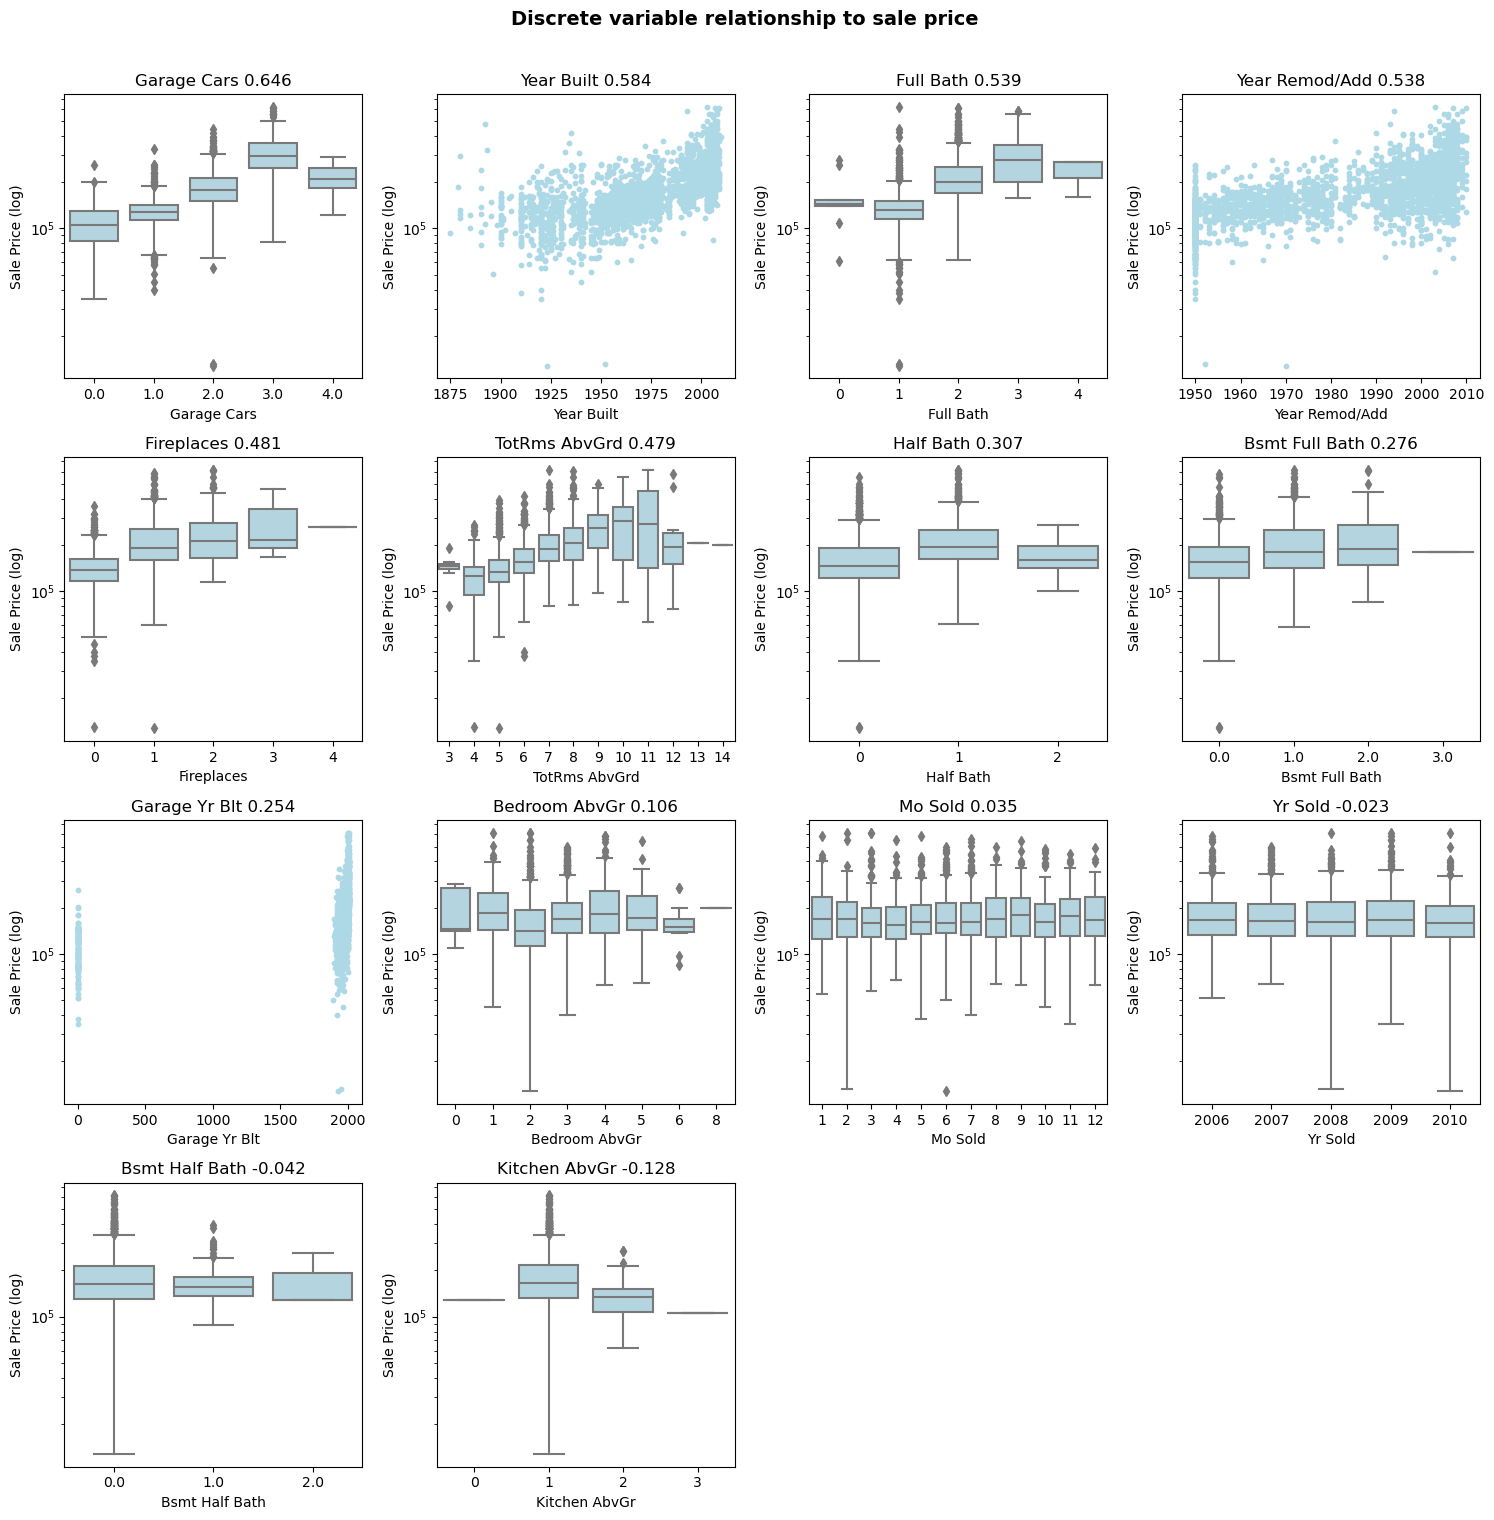

In [46]:
# Scatter and box plots for the discrete columns 
import math

# compute the number of rows and columns for the subplot
n_col = 4
n_rows = math.ceil(len(disc_col) / n_col)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 15))
axes = axes.flatten()

for col, i in zip(correlations_disc.index, range(len(disc_col))):
        if col in ("Year Built", "Year Remod/Add", "Garage Yr Blt"):
            axes[i].scatter(df[col], df["SalePrice"], s=10, color="lightblue")
        else:
            sns.boxplot(data=df, x=col, y="SalePrice", ax=axes[i], color="lightblue")
        axes[i].set_title(str(col) + " " + str(round(correlations_disc[col], 3)))
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Sale Price (log)")
        axes[i].set_yscale("log")

# Remove unused subplots
for j in range(len(disc_col), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Discrete variable relationship to sale price", fontsize=14, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()

For some of these Features, the correlation should to be taken with a grain of salt: 
- Garage Yr Built: this feature has a lot of 0s that influence the correlation analysis
- Several features have very low number of values possible (Such as Kitchen above ground or Bsmt Half Bath), here as well the correlation may not be very indicative. 
- For features such as Month and Year sold, a correlation might not be able to show fluctuations (or non linear relationships) in the data. 

However, when looking at both the correlation and the plots, we observe that some features clearly do not seem to be related to the sale price and could be removed from our analysis. 

The features that I will remove are:
- Yr Sold
- Mo Sold
- Bsmt Half Bath

In [47]:
df = df.drop(["Yr Sold", "Mo Sold", "Bsmt Half Bath"], axis=1)

# update the feature list
disc_col = [col for col in disc_col if col not in ("Yr Sold", "Mo Sold", "Bsmt Half Bath")]

#### **e) Identifying and adressing rare values**

We will now have a look at the distribution of the data using histograms to see if there are any rare values that should be removed from the data set.

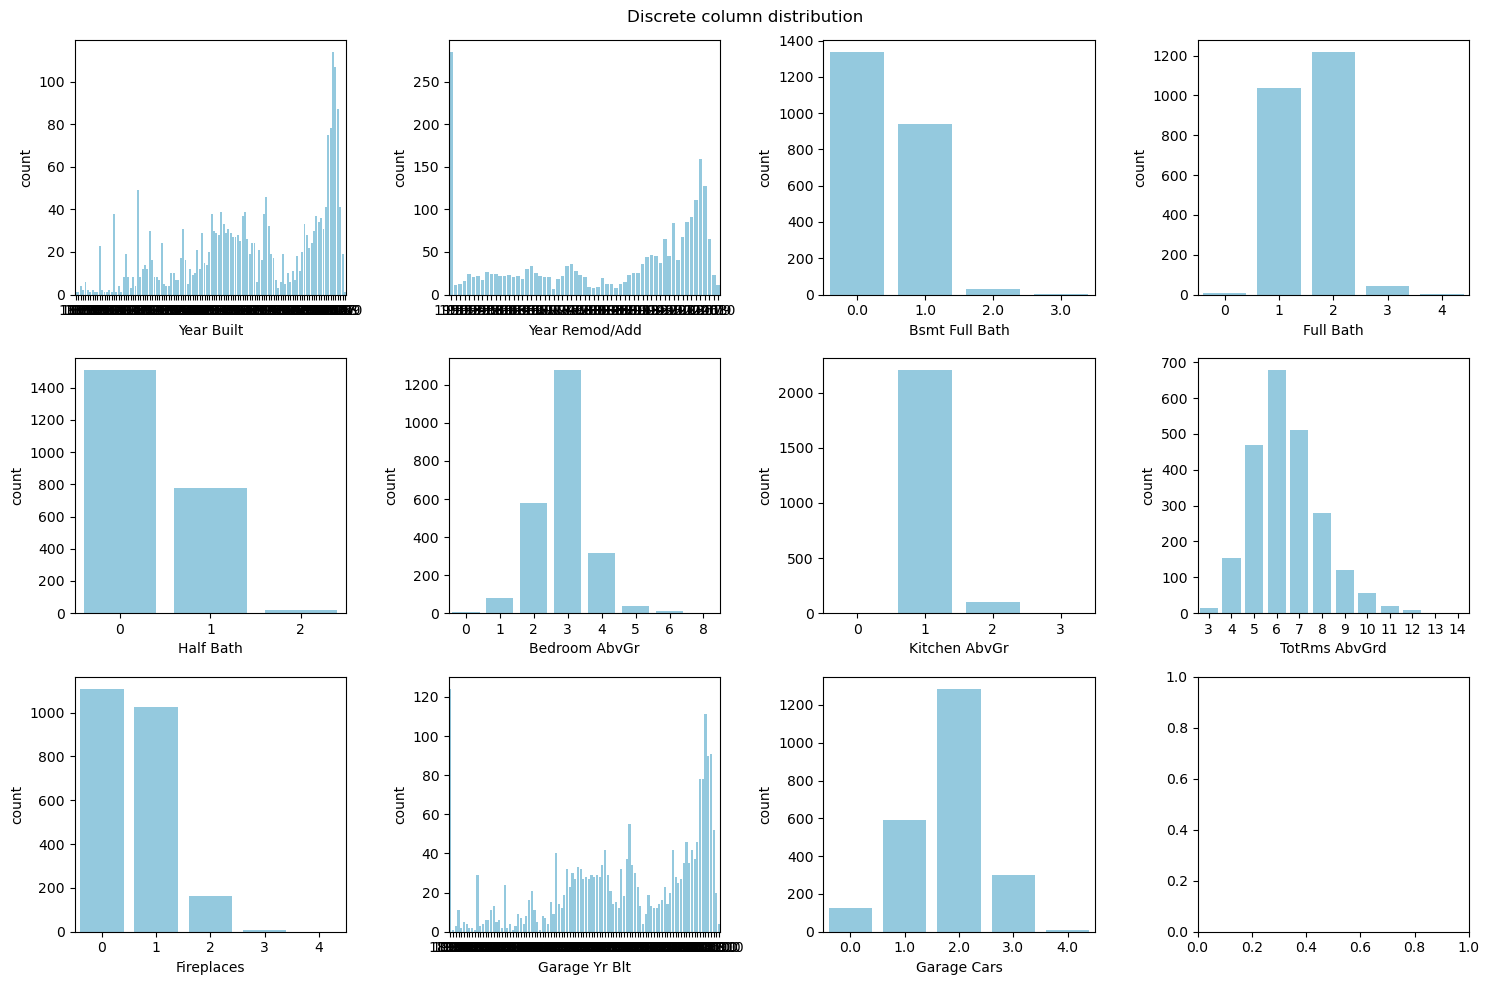

In [48]:
import math

# compute the number of rows and columns for the subplot
n_col = 4
n_rows = math.ceil(len(disc_col) / n_col)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
axes = axes.flatten()

for col, i in zip(disc_col, range(len(col))):
    sns.countplot(x=col, data=df, ax=axes[i], color="skyblue")

    
plt.suptitle("Discrete column distribution")
plt.tight_layout()
plt.show()

From what we can see of the data distribution, doing an outlier removal using a z-score for instance would not make sense for a lot of these variables. I am also hesitant about removing rare values as they might still be relevant for the model. As our data set is relatively small, it might be worth checking some of these features individually.

Here are the features that I will investigate further:
- Half Bath
- Full Bath
- Bedroom AbvGr
- Kitchen AbvGr
- Year Built

I took this decision because a "normal" house should at least have one bedroom, one kitchen and one bathroom. Houses that don't have this are likely "weird" and it might be worth removing them from the data set.

Additionally, for the **Year Built** feature, we could perform an outlier removal using quantiles to remove extreme values. This method doesn't require the distribution to be normal and would thus be well suited for outlier removal in this case.

Something else that stands out is that there are a lot of values seemingly around 1950 for the feature "Year Remod/Add". These values likely represent houses that haven't been renovated, but it might make more sense to replace this with the year the house was built. This is something that we will adress in the "Feature Engineering" section.

##### **Bathroom Features**

For the Bathroom features, before taking the decision to remove rare values, we could combine them into a single feature (total baths) that is the sum of Half Baths and Full Baths. After doing this, we can have a better understanding of the situation of the houses regarding bathrooms

In [49]:
df["Total Baths"] = df["Full Bath"] + 0.5*df["Half Bath"]

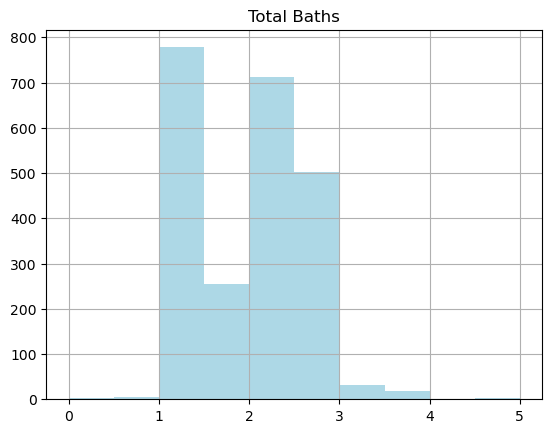

In [50]:
df["Total Baths"].hist(color="lightblue")
plt.title("Total Baths")
plt.show()

In [51]:
print(df["Total Baths"].value_counts())
print(df["Total Baths"].value_counts(normalize=True)*100)

1.0    778
2.0    713
2.5    503
1.5    255
3.0     32
3.5     18
0.5      4
5.0      3
0.0      2
4.0      1
Name: Total Baths, dtype: int64
1.0    33.694240
2.0    30.879168
2.5    21.784322
1.5    11.043742
3.0     1.385881
3.5     0.779558
0.5     0.173235
5.0     0.129926
0.0     0.086618
4.0     0.043309
Name: Total Baths, dtype: float64


Now looking at this new Feature, we see that there are still houses with only 0 or 0.5 above ground bathrooms. We could take the decision to remove these entries, as this doesn't make a lot of sense and these houses are likely unusual houses (or there was a mistake made when entering the data). Let's also remove the houses with 5 bathrooms, as they are clearly extreme cases (and represent less than 0.2% of the data). 

Also let's now remove the two previous bathroom features, as the information is already combined in "Total Baths"

In [52]:
df = df[df["Total Baths"].between(0.5, 4)]

In [53]:
df = df.drop(["Full Bath", "Half Bath"], axis=1)
disc_col = [col for col in disc_col if col not in ("Full Bath", "Half Bath")]

##### **Kitchen Feature**
Let's now take a closer look at the Kitchen feature, as it looks like some house have 0 kitchen listed, which seems weird.

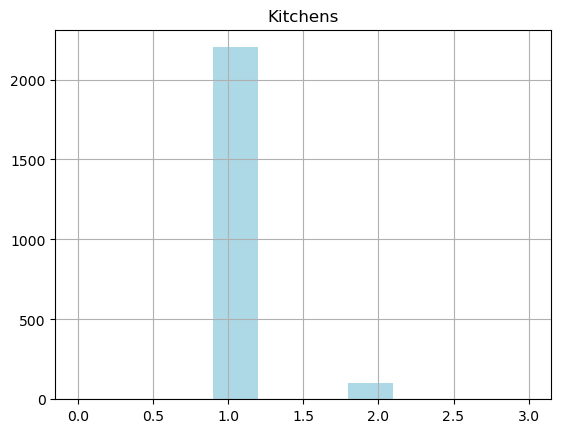

In [54]:
df["Kitchen AbvGr"].hist(color="lightblue")
plt.title("Kitchens")
plt.show()

In [55]:
print(df["Kitchen AbvGr"].value_counts())
print(df["Kitchen AbvGr"].value_counts(normalize=True)*100)

1    2202
2      99
0       2
3       1
Name: Kitchen AbvGr, dtype: int64
1    95.572917
2     4.296875
0     0.086806
3     0.043403
Name: Kitchen AbvGr, dtype: float64


As we thought, there are two houses without any kitchens. Let's remove these from the data set. Let's also remove the house with 3 kitchens, as this is clearly an extreme value as well.

In [56]:
df = df[df["Kitchen AbvGr"].between(1, 2)]

##### **Bedroom Feature**

Finally, Let's have a look at the Bedroom above ground feature.

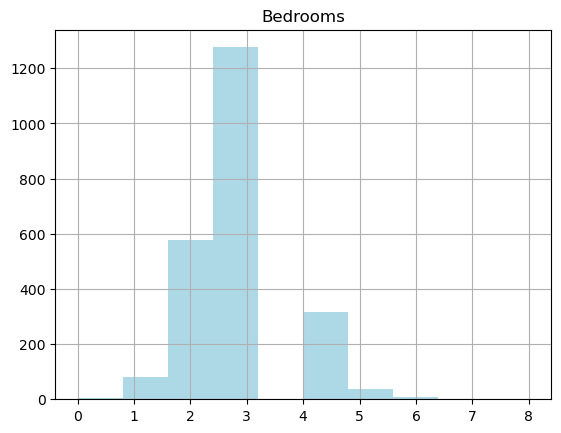

In [57]:
df["Bedroom AbvGr"].hist(color="lightblue")
plt.title("Bedrooms")
plt.show()

In [58]:
print(df["Bedroom AbvGr"].value_counts())
print(df["Bedroom AbvGr"].value_counts(normalize=True)*100)

3    1276
2     577
4     315
1      79
5      38
6      10
0       5
8       1
Name: Bedroom AbvGr, dtype: int64
3    55.454150
2    25.076054
4    13.689700
1     3.433290
5     1.651456
6     0.434594
0     0.217297
8     0.043459
Name: Bedroom AbvGr, dtype: float64


Let's have a look at the two houses that have 0 bedrooms (and see if this is a mistake or if they are studios for instance, in which case we might still wish to keep them). Let's investigate the Sale Price for these houses and see if it is clearly below average.

In [59]:
print("Sale price for the two houses with 0 bedrooms:", df.loc[(df["Bedroom AbvGr"] == 0), "SalePrice"].values)
print("median sale price", df.SalePrice.median())

Sale price for the two houses with 0 bedrooms: [260000 108959 140000 286000 279000]
median sale price 163000.0


This information clearly points towards there being an error with these two entries as the sale price is in one case above the median sale price of the data set, and in another case not drastically lower. Let's remove these two entries from the data set. Let's also remove the house with 8 bedrooms, as this is likely a mansion and an extreme value that wouldn't add any valuable information to our model.

In [60]:
df = df[df["Bedroom AbvGr"].between(1, 7)]

##### **Year Built Feature**
For this feature, we can perform outlier removal using quantiles. We could remove the 2% houses with the oldest year of construction for instance, as these are clearly extreme values. I don't want to remove any of the newer houses, as they could be useful for the model. Let's start by calculating the value corresponding to the 3rd quantile, and let's then filter any houses older than that. 

In [61]:
threshold_value = df["Year Built"].quantile(q=0.02)
print("we will remove houses built before", threshold_value)

mask = df["Year Built"] <= threshold_value

print("this consists of", mask.sum(), "houses (", mask.sum()/len(df) * 100, "% )")

we will remove houses built before 1903.7600000000002
this consists of 46 houses ( 2.0043572984749454 % )


This seems like an appropriate filtering strategy. Let's filter our data based on this filter.

In [62]:
df = df[~mask]

### **2.3) Exploring the nominal variables**
We will now look at the nominal variables. 

#### **a) Identifying and addressing missing values**
Let's start by looking at how much of the data is missing for the nominal features.

In [63]:
# identify missing values
for col in nom_col:
    print("Missing values for", col, ":", df[col].isna().sum(), "(", df[col].isna().sum() / len(df) * 100, "% )")

Missing values for MS SubClass : 0 ( 0.0 % )
Missing values for MS Zoning : 0 ( 0.0 % )
Missing values for Street : 0 ( 0.0 % )
Missing values for Alley : 2118 ( 94.17518897287684 % )
Missing values for Land Contour : 0 ( 0.0 % )
Missing values for Lot Config : 0 ( 0.0 % )
Missing values for Neighborhood : 0 ( 0.0 % )
Missing values for Condition 1 : 0 ( 0.0 % )
Missing values for Condition 2 : 0 ( 0.0 % )
Missing values for Bldg Type : 0 ( 0.0 % )
Missing values for House Style : 0 ( 0.0 % )
Missing values for Roof Style : 0 ( 0.0 % )
Missing values for Roof Matl : 0 ( 0.0 % )
Missing values for Exterior 1st : 0 ( 0.0 % )
Missing values for Exterior 2nd : 0 ( 0.0 % )
Missing values for Mas Vnr Type : 19 ( 0.8448199199644287 % )
Missing values for Foundation : 0 ( 0.0 % )
Missing values for Heating : 0 ( 0.0 % )
Missing values for Central Air : 0 ( 0.0 % )
Missing values for Garage Type : 112 ( 4.979991107158737 % )
Missing values for Misc Feature : 2167 ( 96.35393508225877 % )
Missing

There are clearly some features that seem to contain a lot of missing values! In the "Alley" and the "Misc Feature" Variables, at least 90% of the data is missing. Let's plot these columns and remove these features from our data set if they do not seem to contribute to sale price. 

The other two features that we will look at in more detail are "Garage Type" and "Mas Vnr Type". 

##### **Addressing Misc Feature and Alley**
To fully visualize the data, let's first fill in the missing values with "none"

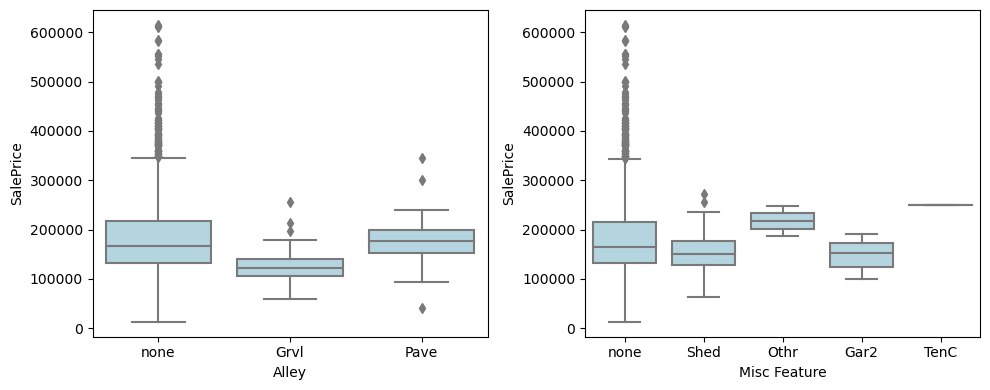

In [64]:
df["Alley"].fillna("none", inplace=True)
df["Misc Feature"].fillna("none", inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.boxplot(data=df, x="Alley", y="SalePrice", ax=axes[0], color="lightblue")
sns.boxplot(data=df, x="Misc Feature", y="SalePrice", ax=axes[1], color="lightblue")

plt.tight_layout()
plt.show()

It does seem like the for both of the features, the different categories have different sale prices. But how many houses does this really concern ? Let's check this using value_counts.

In [65]:
print(df["Alley"].value_counts())
print(df["Alley"].value_counts(normalize=True)*100)

none    2118
Grvl      85
Pave      46
Name: Alley, dtype: int64
none    94.175189
Grvl     3.779458
Pave     2.045353
Name: Alley, dtype: float64


In [66]:
print(df["Misc Feature"].value_counts())
print(df["Misc Feature"].value_counts(normalize=True)*100)


none    2167
Shed      74
Gar2       5
Othr       2
TenC       1
Name: Misc Feature, dtype: int64
none    96.353935
Shed     3.290351
Gar2     0.222321
Othr     0.088928
TenC     0.044464
Name: Misc Feature, dtype: float64


It really seems like very few houses are concerned (especially in the Misc Features column). Let's simply remove these two features, as they likely don'd add much value to our model.

In [67]:
# Removing the two problematic columns
df = df.drop(["Alley", "Misc Feature"], axis=1)
nom_col = [col for col in nom_col if col not in ("Alley", "Misc Feature")]

##### **Filling the missing values in "Garage Type"**

One hypothesis could be that this feature is empty when the houses don't have a garage. We can check this by looking at the Garage Area feature (if it is 0, the houses don't have a garage). 

In [68]:
print("Percentage of missing values that actually don't have a garage:", ((df["Garage Area"] == 0) & (df["Garage Type"].isna())).sum() / df["Garage Type"].isna().sum() * 100)

Percentage of missing values that actually don't have a garage: 100.0


As we hypothesized, all of these entries are empty since the houses they correspond to don't have a garage. Let's now investigate what would be the best approach to fill these empty values. 

Let's look more closely at the possible values for this feature. 

In [69]:
print(df["Garage Type"].value_counts())

Attchd     1378
Detchd      565
BuiltIn     140
Basment      27
2Types       19
CarPort       8
Name: Garage Type, dtype: int64


I will replace the missing values by the value "NoGrg".

In [70]:
df.loc[df["Garage Type"].isna(), "Garage Type"] = "NoGrg"
df["Garage Type"].value_counts()

Attchd     1378
Detchd      565
BuiltIn     140
NoGrg       112
Basment      27
2Types       19
CarPort       8
Name: Garage Type, dtype: int64

##### **Filling the missing values in "Mas Vnr Type"**

We can take a similar approach for this feature. It is possible that the missing values correspond to houses without masonry veneer. Let's check this and if it is the case, let's fill in the missing values with "NoMasVnr"

In [71]:
print("Percentage of missing values that actually don't have a Masonry Veneer:", ((df["Mas Vnr Area"] == 0) & (df["Mas Vnr Type"].isna())).sum() / df["Mas Vnr Type"].isna().sum() * 100)

Percentage of missing values that actually don't have a Masonry Veneer: 100.0


In [72]:
df["Mas Vnr Type"].value_counts()

None       1316
BrkFace     692
Stone       201
BrkCmn       20
CBlock        1
Name: Mas Vnr Type, dtype: int64

In [73]:
# Filling in empty values
df.loc[df["Mas Vnr Type"].isna(), "Mas Vnr Type"] = "NoMasVnr"
df["Mas Vnr Type"].value_counts()

None        1316
BrkFace      692
Stone        201
BrkCmn        20
NoMasVnr      19
CBlock         1
Name: Mas Vnr Type, dtype: int64

In [74]:
df[nom_col].isna().sum()

MS SubClass       0
MS Zoning         0
Street            0
Land Contour      0
Lot Config        0
Neighborhood      0
Condition 1       0
Condition 2       0
Bldg Type         0
House Style       0
Roof Style        0
Roof Matl         0
Exterior 1st      0
Exterior 2nd      0
Mas Vnr Type      0
Foundation        0
Heating           0
Central Air       0
Garage Type       0
Sale Type         0
Sale Condition    0
dtype: int64

Our data cleaning strategy worked! We don't have any missing values in the nominal columns anymore.

#### **b) Removing features with low impact on sale price**

Let's now plot the nominal features to see if there are some that don't seem to have an influence on the sale price. We won't be looking at correlation here since this metric doesn't make sense for nominal features. We will start by making boxplots to investigate the individual features

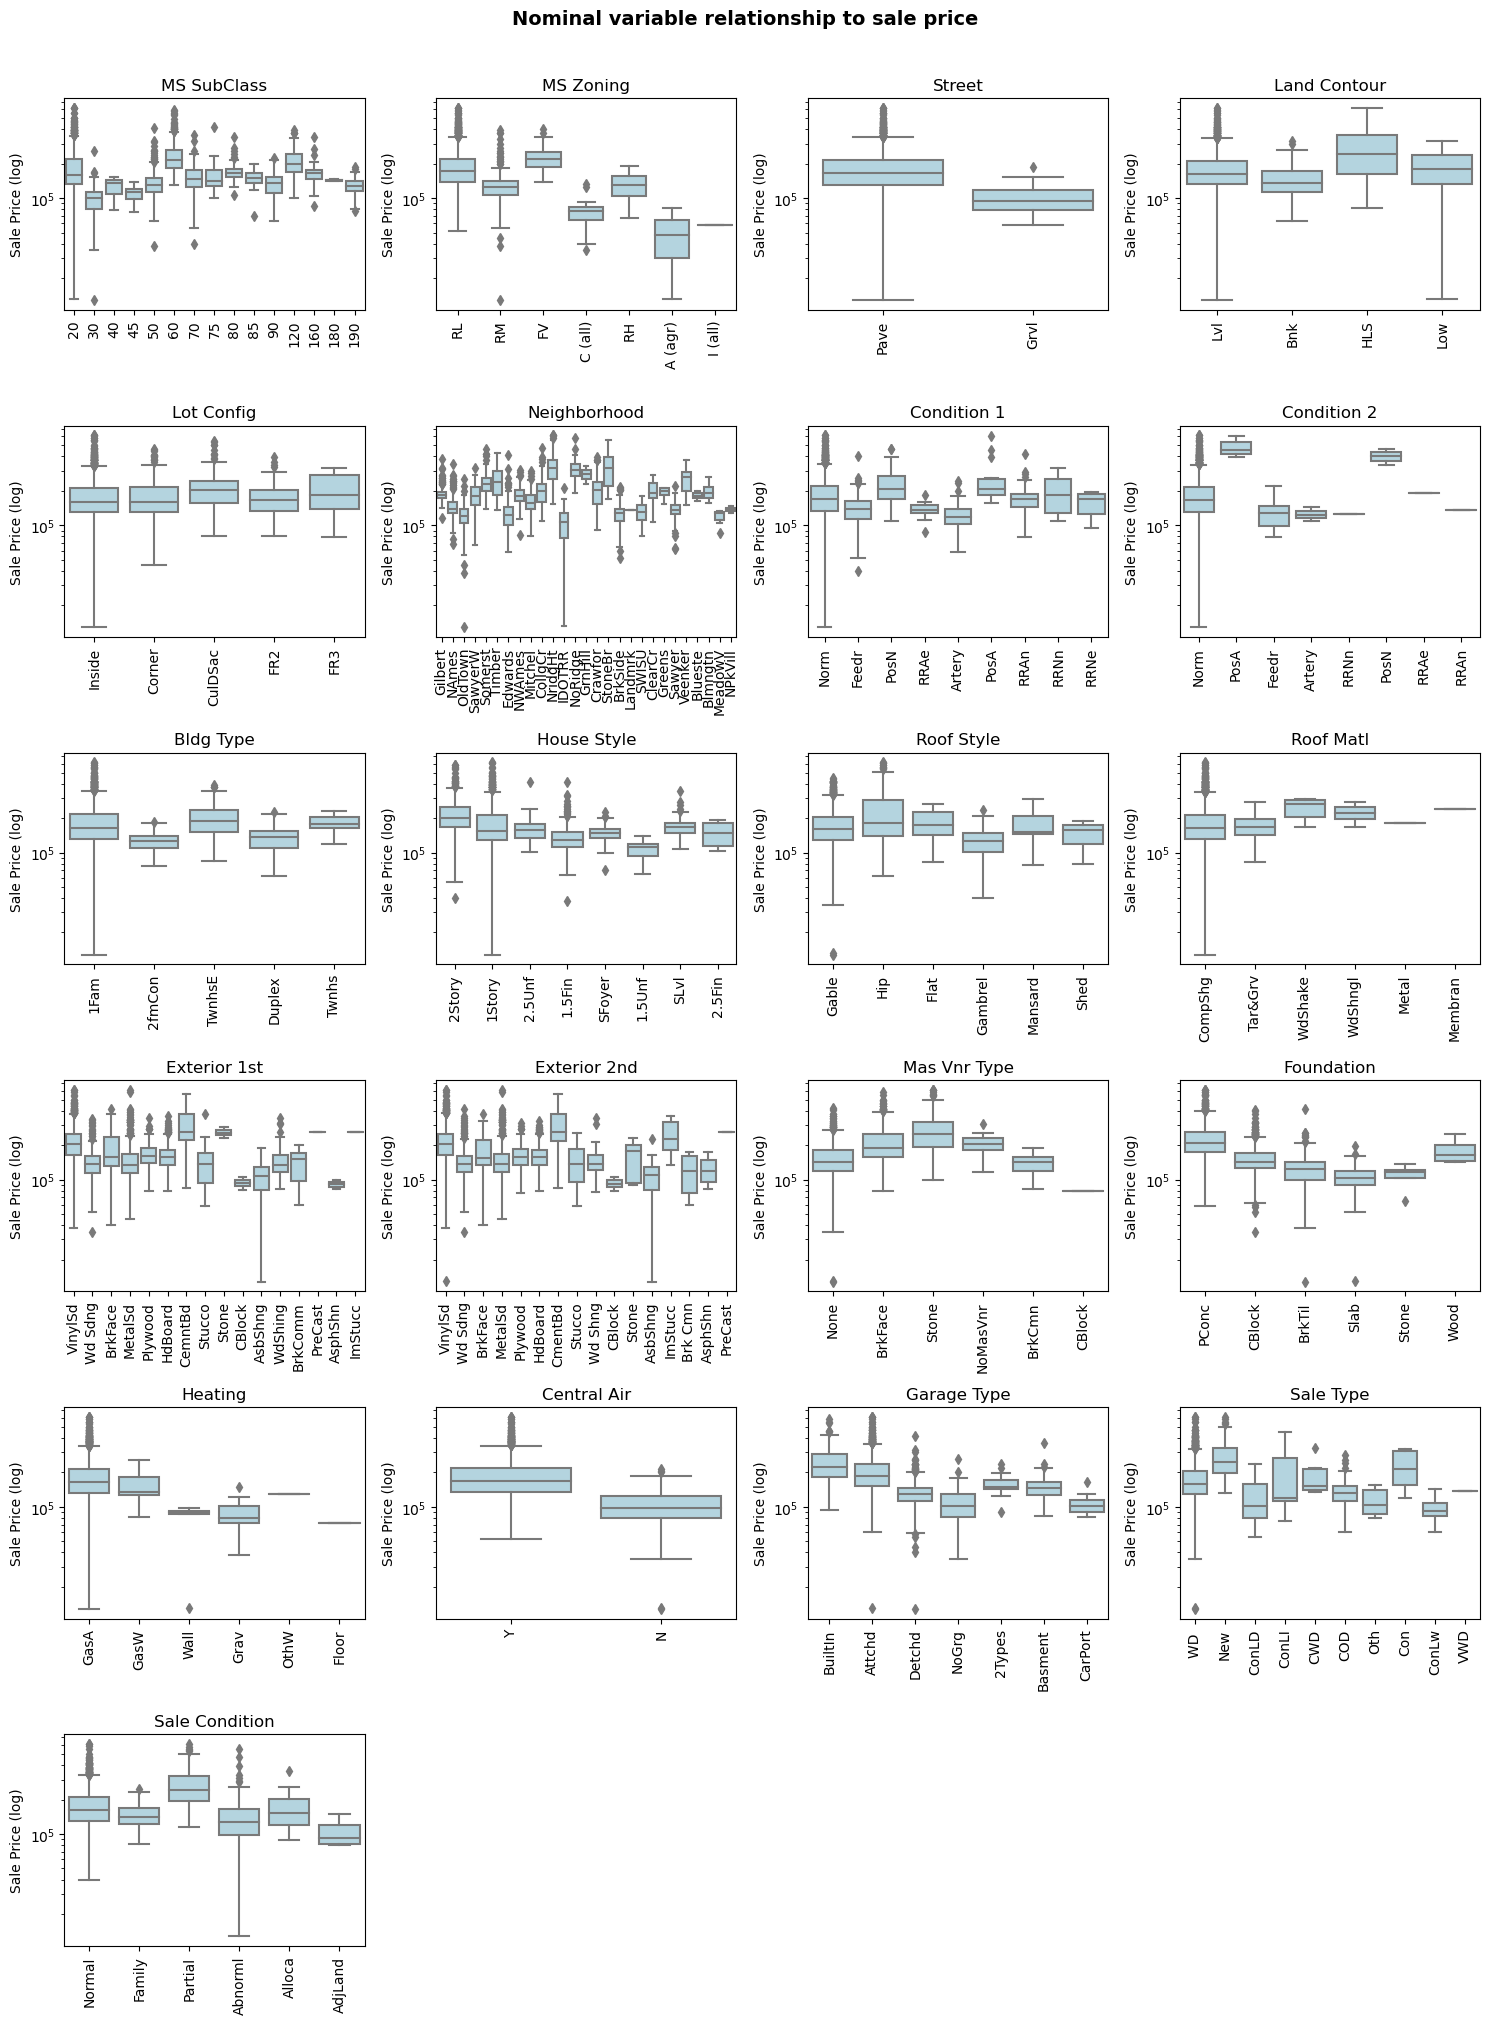

In [75]:
# Boxplots for the nominal columns 
import math

# compute the number of rows and columns for the subplot
n_cols = 4
n_rows = math.ceil(len(nom_col) / n_col)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 20))
axes = axes.flatten()

for col, i in zip(nom_col, range(len(nom_col))):
        sns.boxplot(data=df, x=col, y="SalePrice", ax=axes[i], color="lightblue")
        axes[i].set_title(col)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Sale Price (log)")
        axes[i].set_yscale("log")
        axes[i].tick_params(axis='x', rotation=90)

# Remove unused subplots
for j in range(len(nom_col), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Nominal variable relationship to sale price", fontsize=14, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()

Interestingly, at a first glance, most of these variables seem to influence the sale price (some more drastically than others). An example of a feature that has a strong influence on the sale price is the neighborhood. An example of a feature that does not seem to have an influence on the sale price is the Lot Config feature. Let's remove it. I will take the decision not to remove any other features, as they all seem to have an influence on the sale price.

In [76]:
df = df.drop("Lot Config", axis=1)
nom_col = [col for col in nom_col if col not in ("Lot Config")]

#### **c) Identifying and addressing rare values**

For the nominal features, something we could do is group all rare values into a category called "other". Let's pool all values containing less than 0.5% of the data into a new value "other". 

If pooling the categories together still hasn't made an "other" cateogry containing more than 0.5% of the variable, let's remove it all together (these are not ordinary houses). 

In [78]:
for col in nom_col:
    rare_values = df[col].value_counts(normalize=True) < 0.005
    rare_values = rare_values[rare_values].index
    # If there is more than 1 rare index, group the different categories into a category "other". 
    if len(rare_values) > 1 :
        df.loc[df[col].isin(rare_values), col] = "other"
        if ((df[col] == "other").sum() / len(df[col])) < 0.005:
            df = df[df[col] != "other"] # Remove the category "other" if it still contains less than 0.25% of the data
    else:
        df = df[~df[col].isin(rare_values)] # Remove the category if it is "alone" and contains less than 0.25% of the data

Let's visualize the data once more to make sure that this strategy worked as intended:

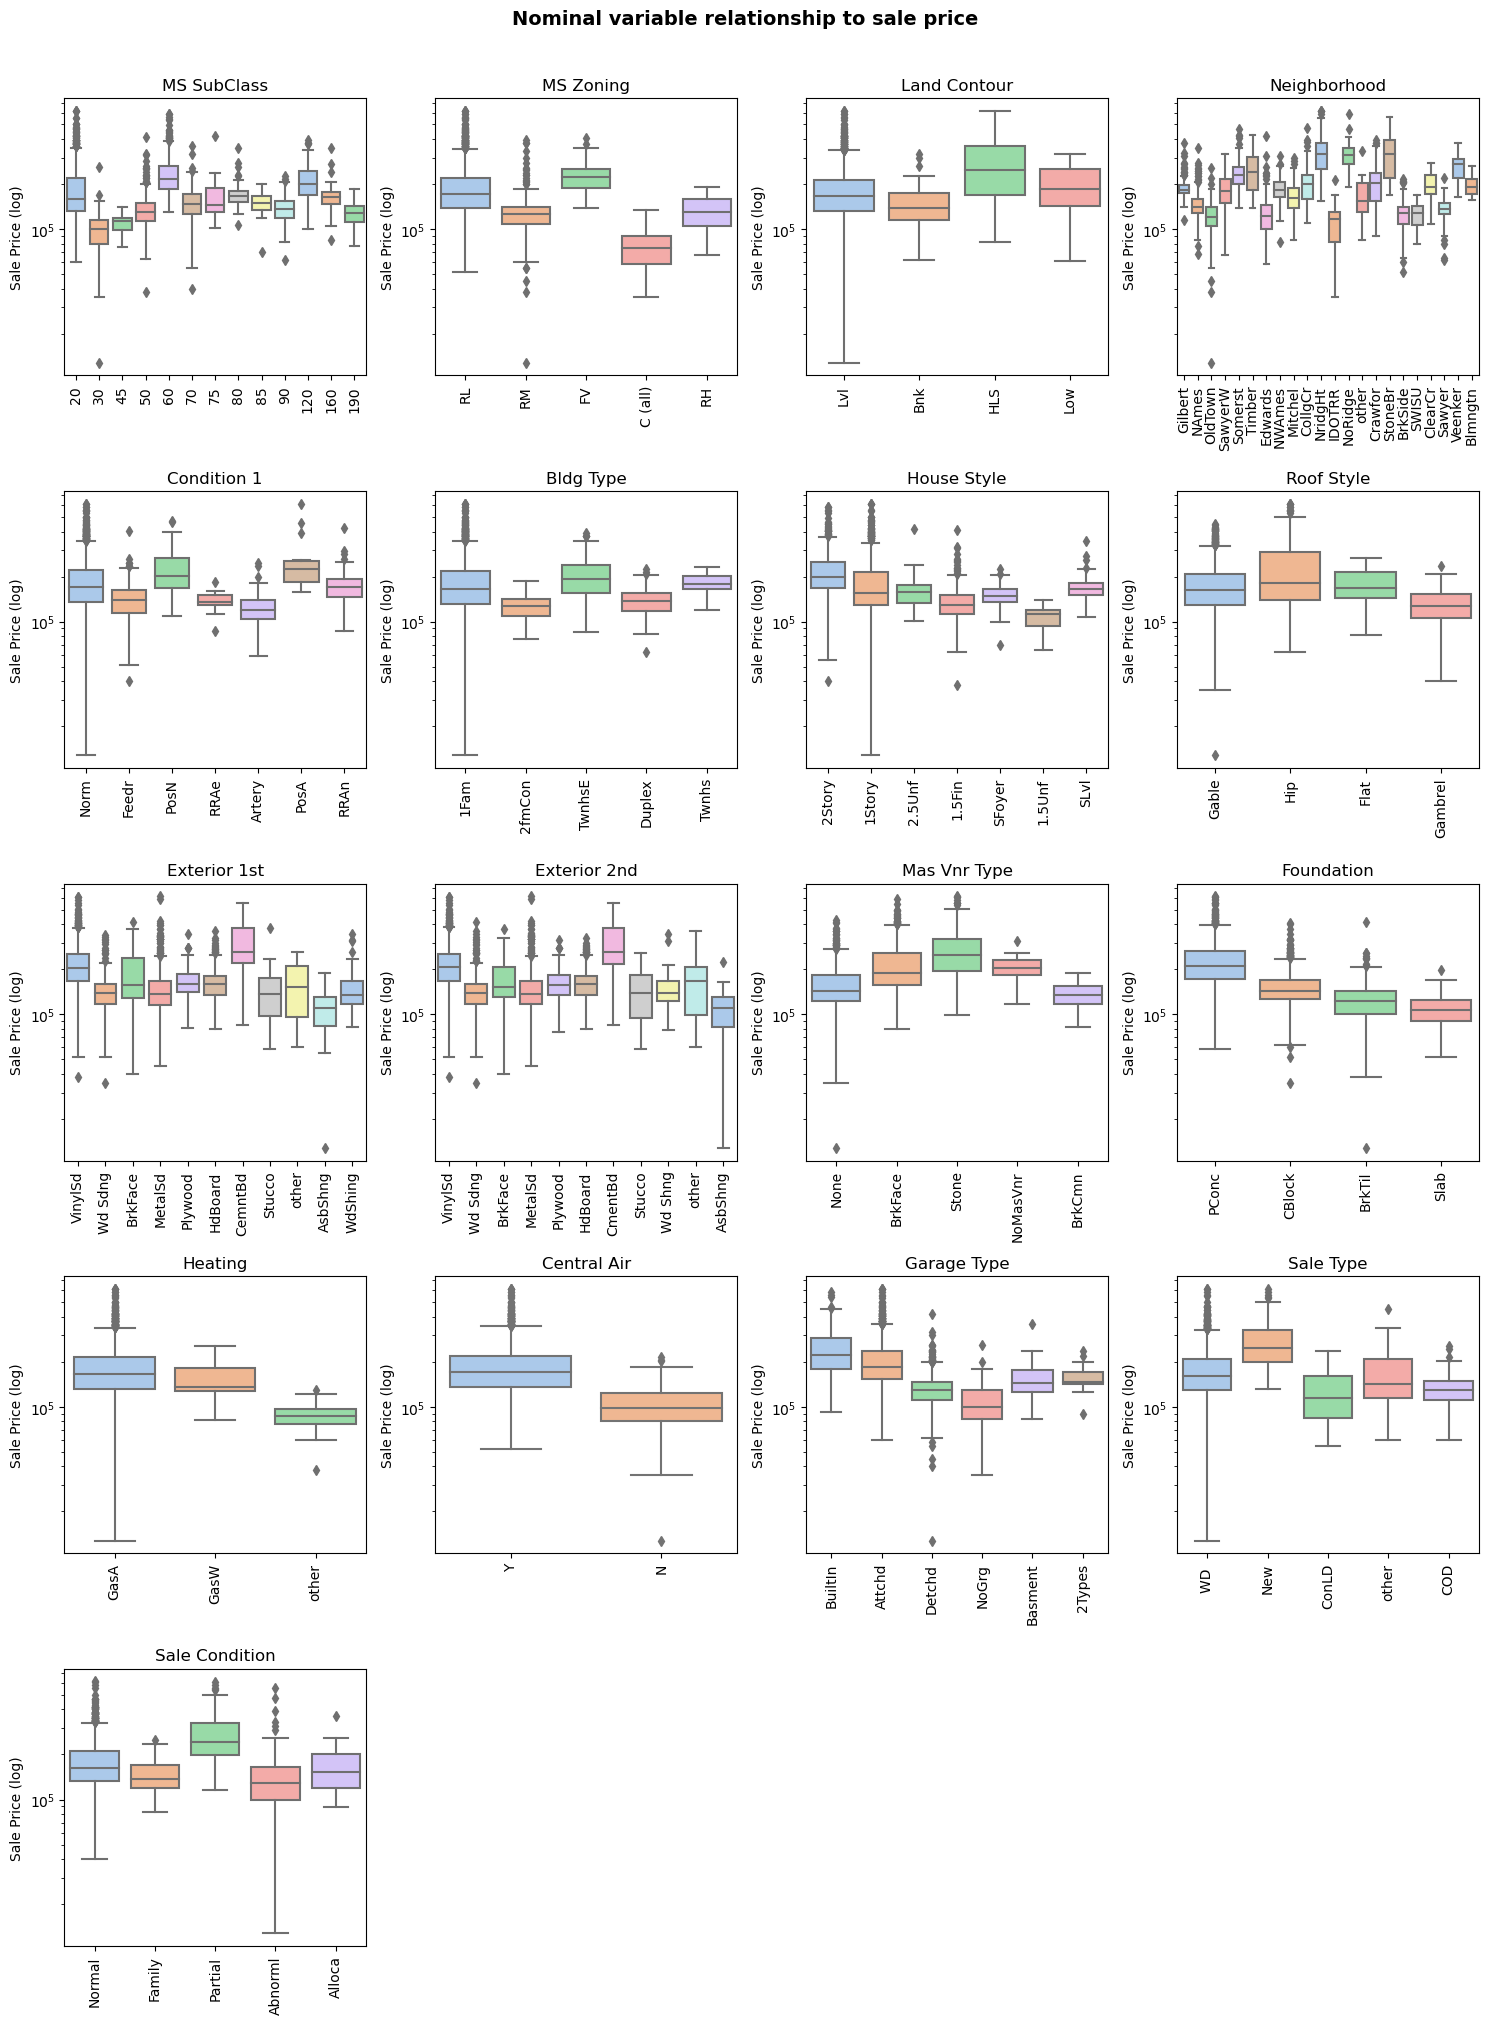

In [82]:
# Boxplots for the nominal columns 
import math

# compute the number of rows and columns for the subplot
n_cols = 4
n_rows = math.ceil(len(nom_col) / n_col)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 20))
axes = axes.flatten()

for col, i in zip(nom_col, range(len(nom_col))):
        sns.boxplot(data=df, x=col, y="SalePrice", ax=axes[i], palette="pastel")
        axes[i].set_title(col)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Sale Price (log)")
        axes[i].set_yscale("log")
        axes[i].tick_params(axis='x', rotation=90)

# Remove unused subplots
for j in range(len(nom_col), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Nominal variable relationship to sale price", fontsize=14, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()

We see that we now have the category "other" for most variables. 

Our filtering strategy has worked, but has also now made some features useless for the model. This is the case for the feature "Street" that now only carries one category, or the features "Condition 2" and "Roof Matl" that only contain two categories not related to sale price. We can drop these features from the data set.  

In [81]:
df = df.drop(["Street", "Condition 2", "Roof Matl"], axis=1)
nom_col = [col for col in nom_col if col not in ("Street", "Condition 2", "Roof Matl")]

KeyError: "['Street' 'Condition 2' 'Roof Matl'] not found in axis"

### **2.4) Exploring the ordinal features**
We will now look at the ordinal variables. 

#### **a) Identifying missing values**

Let's have a look at the percentage of missing values in the ordinal features. 

In [83]:
# identify missing values
for col in ord_col:
    print("Missing values for", col, ":", df[col].isna().sum(), "(", df[col].isna().sum() / len(df) * 100, "% )")

Missing values for Lot Shape : 0 ( 0.0 % )
Missing values for Utilities : 0 ( 0.0 % )
Missing values for Land Slope : 0 ( 0.0 % )
Missing values for Overall Qual : 0 ( 0.0 % )
Missing values for Overall Cond : 0 ( 0.0 % )
Missing values for Exter Qual : 0 ( 0.0 % )
Missing values for Exter Cond : 0 ( 0.0 % )
Missing values for Bsmt Qual : 57 ( 2.6182820395039044 % )
Missing values for Bsmt Cond : 57 ( 2.6182820395039044 % )
Missing values for Bsmt Exposure : 60 ( 2.7560863573725314 % )
Missing values for BsmtFin Type 1 : 57 ( 2.6182820395039044 % )
Missing values for BsmtFin Type 2 : 58 ( 2.6642168121267797 % )
Missing values for Heating QC : 0 ( 0.0 % )
Missing values for Electrical : 1 ( 0.045934772622875514 % )
Missing values for Kitchen Qual : 0 ( 0.0 % )
Missing values for Functional : 0 ( 0.0 % )
Missing values for Fireplace Qu : 1015 ( 46.62379421221865 % )
Missing values for Garage Finish : 105 ( 4.823151125401929 % )
Missing values for Garage Qual : 105 ( 4.823151125401929 % )

We immediately see that some features are almost entirely filled with missing values. For instance, the feature "Pool QC" contains 99% of missing values (presumably from houses without a pool). The information if a house has or not a pool is already contained in the feature "Pool Area". We can probably remove this feature alltogether since it is really very empty.

A similar reflexion can be applied to the Feature Fireplace Qu. The feature is partially empty, (because a lot of houses don't have a fireplace), and the information if a house has a fireplace or not is already contained in another variable (number of fireplaces). Let's plot it first to investigate if it influences the sale price. 

Finally, let's also plot the third mainly empty feature (Fence). 

##### **Addressing the mainly empty features**

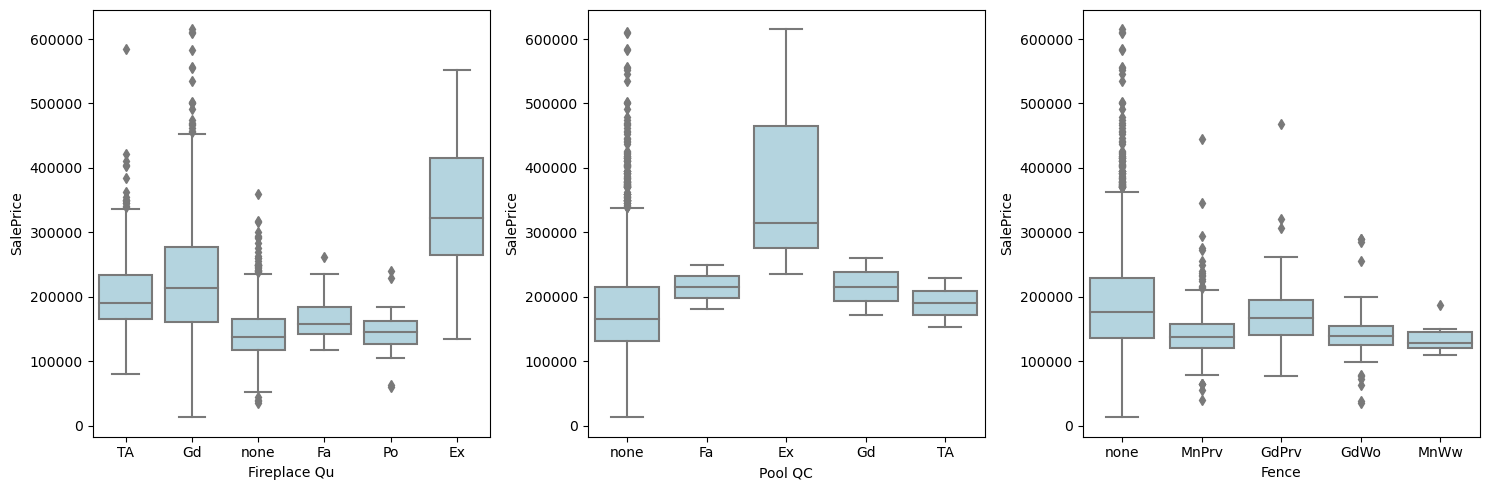

In [84]:
df["Pool QC"].fillna("none", inplace=True)
df["Fireplace Qu"].fillna("none", inplace=True)
df["Fence"].fillna("none", inplace=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df, x="Fireplace Qu", y="SalePrice", ax=axes[0], color="lightblue")
sns.boxplot(data=df, x="Pool QC", y="SalePrice", ax=axes[1], color="lightblue")
sns.boxplot(data=df, x="Fence", y="SalePrice", ax=axes[2], color="lightblue")
plt.tight_layout()
plt.show()

In [85]:
# Value counts
print(df["Fireplace Qu"].value_counts(normalize=True)*100)
print(df["Pool QC"].value_counts(normalize=True)*100)
print(df["Fence"].value_counts(normalize=True)*100)

none    46.623794
Gd      26.963712
TA      20.257235
Fa       2.756086
Po       1.745521
Ex       1.653652
Name: Fireplace Qu, dtype: float64
none    99.586587
Ex       0.137804
Fa       0.091870
Gd       0.091870
TA       0.091870
Name: Pool QC, dtype: float64
none     79.237483
MnPrv    12.310519
GdWo      4.088195
GdPrv     3.950390
MnWw      0.413413
Name: Fence, dtype: float64


From these three plots and the value count information, I have decided to keep the feature Fireplace Qu, but get rid of the feature Fence (it doesn't seem to influence the sale price very much) and of the Feature Pool QC (there are so little houses in each category that it will likely not add much meaningful information in the model). 

In [86]:
df = df.drop(["Pool QC", "Fence"], axis=1)
ord_col = [col for col in ord_col if col not in ("Pool QC", "Fence")]

##### **Adressing the Basement Features**

For the different basement features (Bsmt Qual, Bsmt Cond, Bsmt Exposure, BsmtFin Type 1, BsmtFin Type 2), the empty values could be related to houses that do not have a basement. 

Let's check this theory by using the feature "Total Bsmt SF" which should be 0 if houses don't have a basement.

In [87]:
for col in ("Bsmt Qual", "Bsmt Cond", "Bsmt Exposure", "BsmtFin Type 1", "BsmtFin Type 2"):    
    print(col, ":", len(df[(df[col].isna()) & (df["Total Bsmt SF"] == 0)]) / df[col].isna().sum() * 100, "% of the missing values are due to not having a basement")

Bsmt Qual : 100.0 % of the missing values are due to not having a basement
Bsmt Cond : 100.0 % of the missing values are due to not having a basement
Bsmt Exposure : 95.0 % of the missing values are due to not having a basement
BsmtFin Type 1 : 100.0 % of the missing values are due to not having a basement
BsmtFin Type 2 : 98.27586206896551 % of the missing values are due to not having a basement


Alright, let's fill in all of the instance where the house does not have a basement with "NoBsmt". 

In [88]:
for col in ("Bsmt Qual", "Bsmt Cond", "Bsmt Exposure", "BsmtFin Type 1", "BsmtFin Type 2"):
    df.loc[(df[col].isna()) & (df["Total Bsmt SF"] == 0), col] = "NoBsmt"
    print(col, ":",  df[col].isna().sum(), "leftover missing values")

Bsmt Qual : 0 leftover missing values
Bsmt Cond : 0 leftover missing values
Bsmt Exposure : 3 leftover missing values
BsmtFin Type 1 : 0 leftover missing values
BsmtFin Type 2 : 1 leftover missing values


Let's now have a look at Bsmt Exposure and Bsmt Fin Type 2. These houses have a basement but this value isn't given. Let's see what the possible values are for these two features.

In [89]:
df["Bsmt Exposure"].value_counts()

No        1396
Av         323
Gd         204
Mn         194
NoBsmt      57
Name: Bsmt Exposure, dtype: int64

Alright, it seems like most houses have the value "No" for the basement exposure. Let's replace the missing value by this.

In [90]:
df["Bsmt Exposure"].fillna(df["Bsmt Exposure"].mode()[0], inplace=True)
df["Bsmt Exposure"].isna().sum()

0

Let's do the same for the "Bsmt Fin Type 2" feature.

In [91]:
df["BsmtFin Type 2"].value_counts()

Unf       1856
Rec         74
LwQ         70
NoBsmt      57
BLQ         56
ALQ         44
GLQ         19
Name: BsmtFin Type 2, dtype: int64

Here as well, let's take the most common feature to fill in the missing values.

In [92]:
df["BsmtFin Type 2"].fillna(df["BsmtFin Type 2"].mode()[0], inplace=True)
df["Bsmt Exposure"].isna().sum()

0

##### **Addressing the Garage Features**

We can now apply a similar logic to the Garage features (Garage Finish, Garage Qual and Garage Cond). Let's first check if these values are empty because the house doesn't have a garage.

In [93]:
for col in ("Garage Finish", "Garage Qual", "Garage Cond"):    
    print(col, ":", len(df[(df[col].isna()) & (df["Garage Area"] == 0)]) / df[col].isna().sum() * 100, "% of the missing values are due to not having a garage")

Garage Finish : 99.04761904761905 % of the missing values are due to not having a garage
Garage Qual : 99.04761904761905 % of the missing values are due to not having a garage
Garage Cond : 99.04761904761905 % of the missing values are due to not having a garage


Let's fill in these cases with "NoGrg"

In [94]:
for col in ("Garage Finish", "Garage Qual", "Garage Cond"):   
    df.loc[(df[col].isna()) & (df["Garage Area"] == 0), col] = "NoGrg"
    print(col, ":",  df[col].isna().sum(), "leftover missing value(s)")

Garage Finish : 1 leftover missing value(s)
Garage Qual : 1 leftover missing value(s)
Garage Cond : 1 leftover missing value(s)


As before, let's replace the leftover missing value by the most common category.

In [95]:
for col in ("Garage Finish", "Garage Qual", "Garage Cond"):   
    df[col].fillna(df[col].mode()[0], inplace=True)
    print(col, ":",  df[col].isna().sum(), "leftover missing value(s)")

Garage Finish : 0 leftover missing value(s)
Garage Qual : 0 leftover missing value(s)
Garage Cond : 0 leftover missing value(s)


In [96]:
df[ord_col].isna().sum()

Lot Shape         0
Utilities         0
Land Slope        0
Overall Qual      0
Overall Cond      0
Exter Qual        0
Exter Cond        0
Bsmt Qual         0
Bsmt Cond         0
Bsmt Exposure     0
BsmtFin Type 1    0
BsmtFin Type 2    0
Heating QC        0
Electrical        1
Kitchen Qual      0
Functional        0
Fireplace Qu      0
Garage Finish     0
Garage Qual       0
Garage Cond       0
Paved Drive       0
dtype: int64

##### **Addressing the Electrical Feature**
There's still on feature with a missing value left to adress, the Electrical feature. Let's have a look at the possible values for that feature and decide what the best course of action is.

In [97]:
df["Electrical"].value_counts()

SBrkr    2002
FuseA     135
FuseF      33
FuseP       5
Mix         1
Name: Electrical, dtype: int64

This feature could be related to the age of the house. Let's plot it in relation to the construction year.

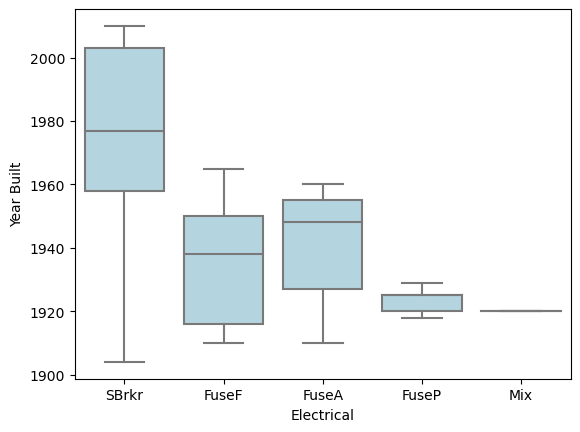

In [98]:
sns.boxplot(data=df, x="Electrical", y="Year Built", color="lightblue")
plt.show()

As expected, only houses built before 1960 have an electrical system other than SBrkr. Let's check the year of the house that doesn't have a feature, and fill the missing value based on the most frequent value for houses that have a similar construction year (+/- 10 years). I know there is only one missing value, but as an exercise, I will code this as if there were more than one missing values.

In [99]:
years = df.loc[df["Electrical"].isna(), "Year Built"]

for index, year in zip(years.index, years.values):
    df.loc[df.index==index, "Electrical"] = df.loc[df["Year Built"].between(year-10, year+10), "Electrical"].mode()[0]

In [100]:
df[ord_col].isna().sum()

Lot Shape         0
Utilities         0
Land Slope        0
Overall Qual      0
Overall Cond      0
Exter Qual        0
Exter Cond        0
Bsmt Qual         0
Bsmt Cond         0
Bsmt Exposure     0
BsmtFin Type 1    0
BsmtFin Type 2    0
Heating QC        0
Electrical        0
Kitchen Qual      0
Functional        0
Fireplace Qu      0
Garage Finish     0
Garage Qual       0
Garage Cond       0
Paved Drive       0
dtype: int64

#### **b) Removing features with low impact on sale price**
Let's now plot the ordinal features to see if there are some that don't seem to have an influence on the sale price. We will make boxplots to investigate the relationship between the features and the sale price.

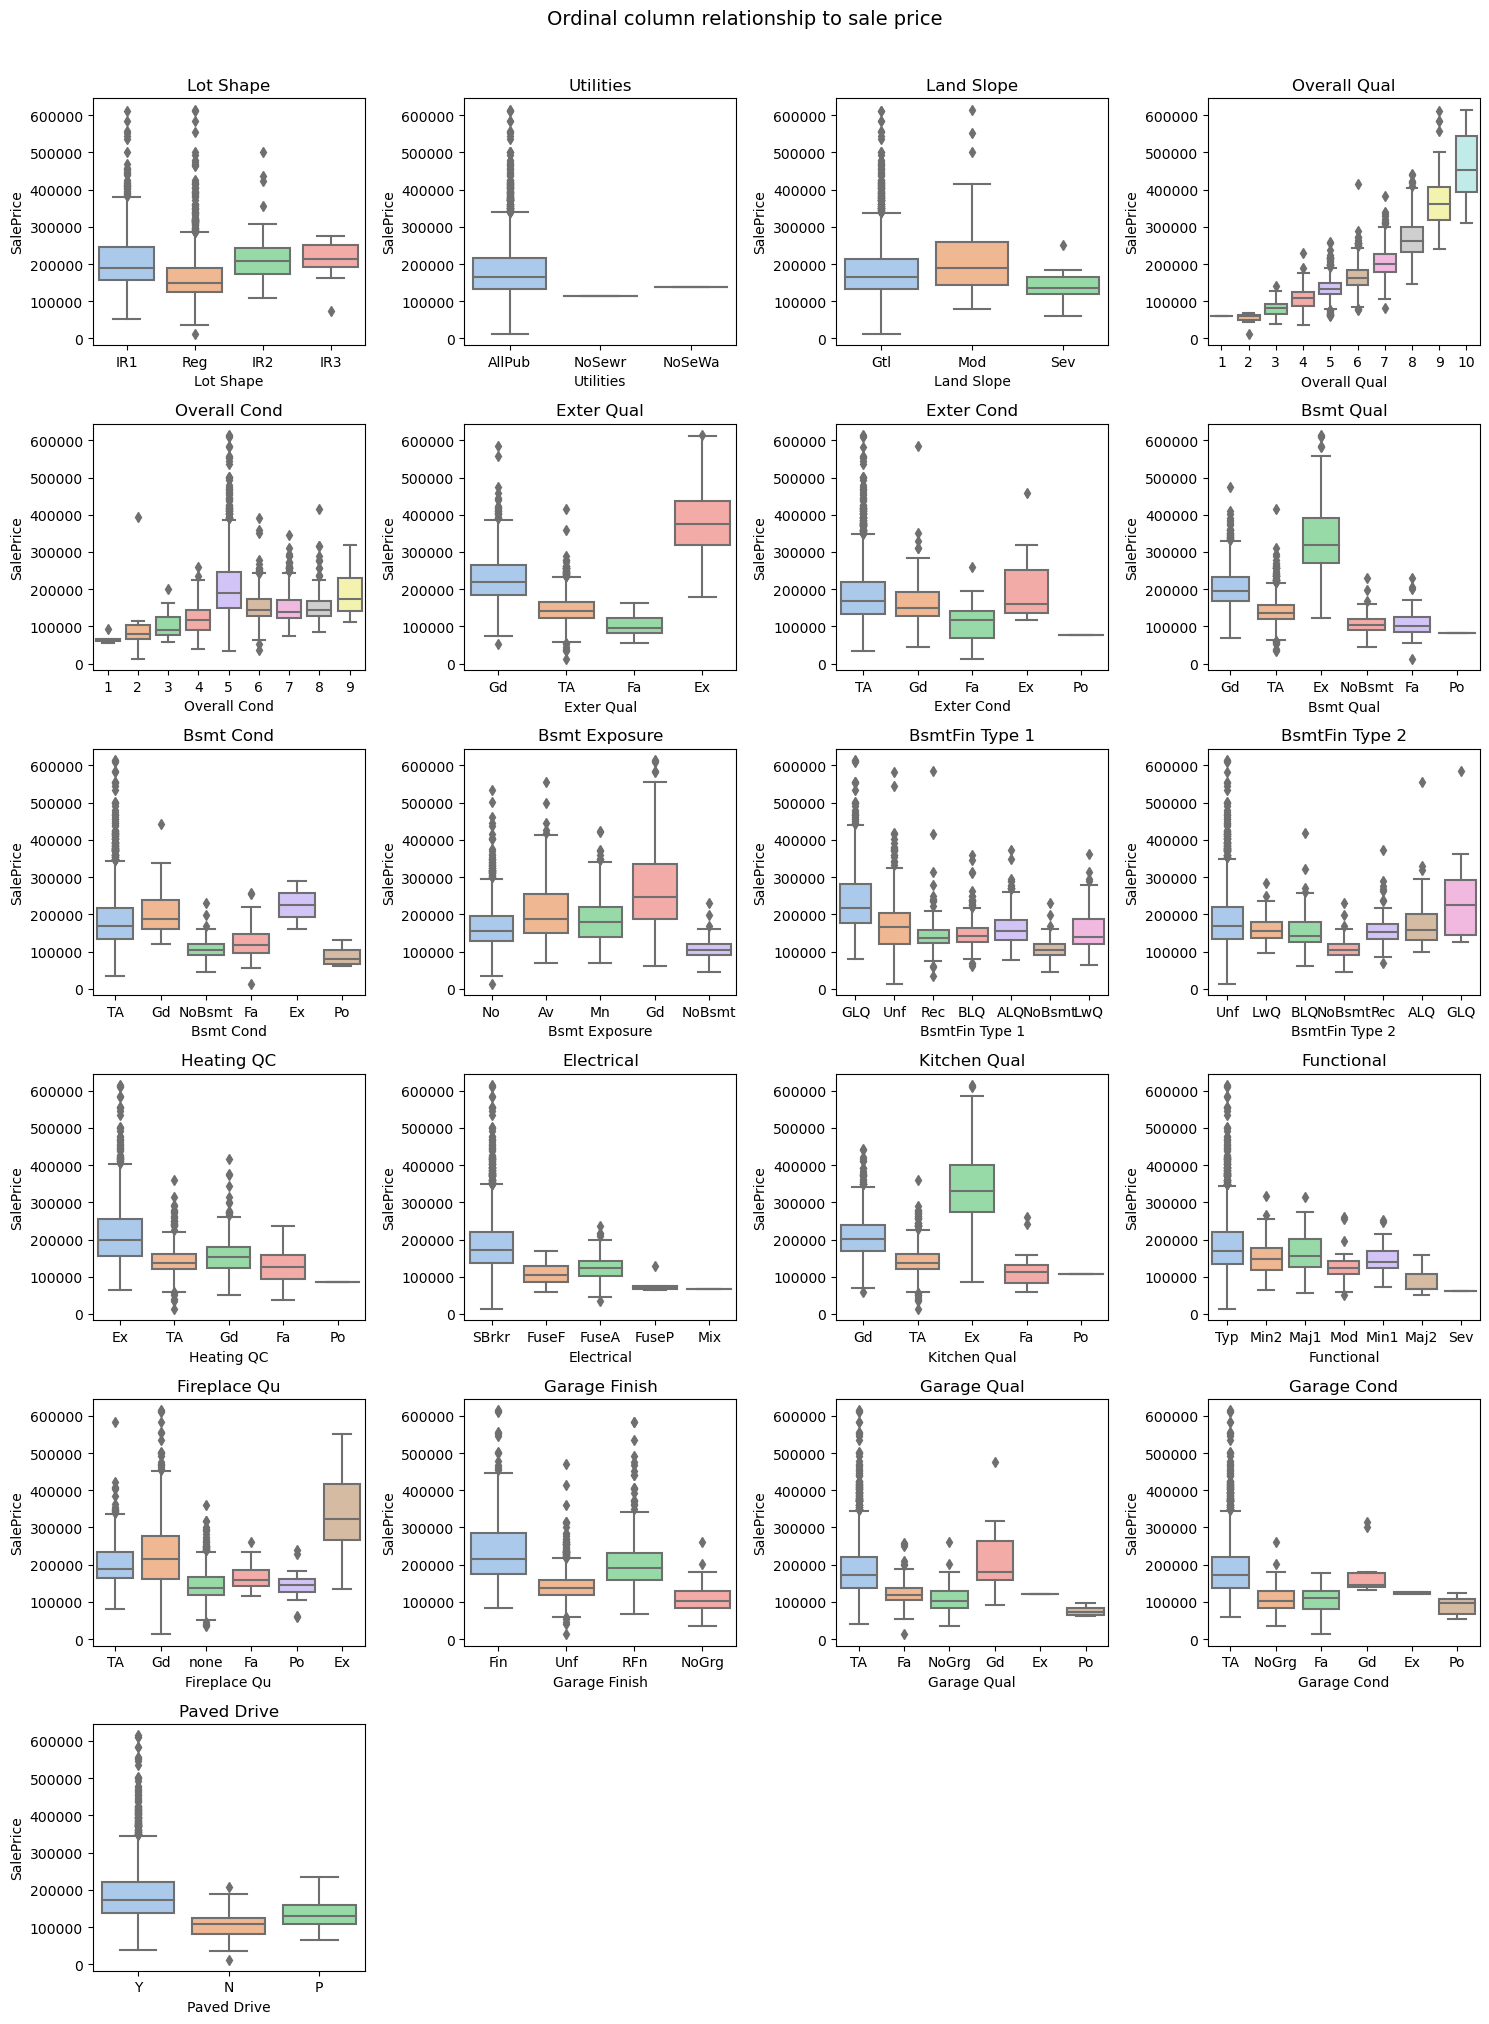

In [101]:
# Boxplots for the ordinal columns 
import math

# compute the number of rows and columns for the subplot
n_cols = 4
n_rows = math.ceil(len(ord_col) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 20))
axes = axes.flatten()

for ax, col in zip(axes, ord_col):
    sns.boxplot(data=df, x=col, y="SalePrice", ax=ax, palette="pastel")
    ax.set_title(col)

# Remove unused subplots
for j in range(len(ord_col), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Ordinal column relationship to sale price", fontsize=14, y=1.01) 
plt.tight_layout()
plt.show()

When looking at the variables one by one, it seems like several of them are not related to the sale price and could be removed. 

Here are the two features that I will remove from the data set as they have a low correlation to the sale price:
- Utilities (also because it seems to contain only one main category)
- Land Slope

In [102]:
df = df.drop(["Utilities", "Land Slope"], axis=1)
ord_col = [col for col in ord_col if col not in ("Utilities", "Land Slope")]

#### **c) Removing rare values**

Since the values are ordinal, Creating a new category called "rare" as we did for the nominal values doesn't necessarily make sense here. The best approach would like to filter out any category that contains less than 0.5% of the data. 


In [103]:
for col in ord_col:
    rare_values = df[col].value_counts(normalize=True) < 0.005
    rare_values = rare_values[rare_values].index
    df = df[~df[col].isin(rare_values)] 


Let's now plot the features again, to see what our filtering did.

In [ ]:
# compute the number of rows and columns for the subplot
n_cols = 4
n_rows = math.ceil(len(ord_col) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 20))
axes = axes.flatten()

for ax, col in zip(axes, ord_col):
    sns.boxplot(data=df, x=col, y="SalePrice", ax=ax, palette="pastel")
    ax.set_title(col)

# Remove unused subplots
for j in range(len(ord_col), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Ordinal column relationship to sale price", fontsize=14, y=1.01) 
plt.tight_layout()
plt.show()

Alright, let's leave the data as it is now!

## **3. Plotting the distribution of the sale prices**

To see if there are any clear outliers or wrong values in the sale price, I will now make two histograms for this variable, one with a linear axis, and one with a log axis

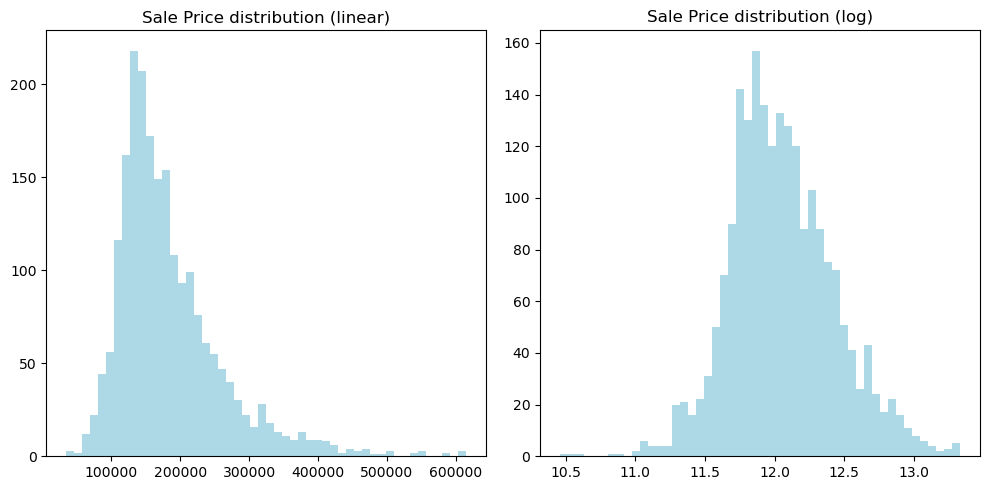

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].hist(df.SalePrice, bins=50, color="lightblue")
axes[0].set_title("Sale Price distribution (linear)")

axes[1].hist(np.log1p(df.SalePrice), bins=50, color="lightblue")
axes[1].set_title("Sale Price distribution (log)")

plt.tight_layout()
plt.show()

We see that the distribution is skewed to the right. It might make sense to log transform this variable. Let's create a new feature that contains the log_transformed sale price and perform outlier removal using a z-score.

In [106]:
df["SalePrice_log"] = np.log(df["SalePrice"])


In [114]:
z_scores = (df["SalePrice_log"] - df["SalePrice_log"].mean()) / df["SalePrice_log"].std()
mask = abs(z_scores) > 3

print("using a z-score removes", mask.sum(), "entries")
print("this corresponds to", mask.sum() / len(df) * 100, "% of the data")

using a z-score removes 15 entries
this corresponds to 0.7088846880907372 % of the data


In [115]:
df = df[~mask]

Finally, let's also remove some entries specifically based on the documentation of the ames data set. 
"There are 5 observations that an instructor may wish to remove from the data set before giving it to students (a plot of SALE PRICE versus GR LIV AREA will indicate them quickly). Three of them are true outliers (Partial Sales that likely don’t represent actual market values) and two of them are simply unusual sales (very large houses priced relatively appropriately). I would recommend removing any houses with more than 4000 square feet from the data set (which eliminates these 5 unusual observations) before assigning it to students."

In [116]:
df = df[df["Gr Liv Area"] < 4000]

## **4. Saving the cleaned data**
Let's now save the cleaned data set.

In [118]:
df.to_csv("clean_df.csv", index=False)